# T-DATA-600 : Évolution des Habitudes d'Achat du Consommateur

## 1. Introduction


### Contexte et problème

Le secteur de la grande distribution évolue. Comprendre les habitudes d'achat des clients est essentiel pour proposer des actions concrètes.

Notre étude répond à cette question : comment les habitudes d'achat changent-elles au fil du temps, selon la fréquence, le moment et les préférences produits ?

### Objectifs de l'analyse

- Analyser la composition et l'évolution des paniers.
- Identifier les produits phares et les marchés de niche.
- Prédire la probabilité de réachat pour anticiper la demande.
- Proposer des actions pour la logistique, le merchandising et les promotions.

### Méthodologie détaillée

- **Préparation des données :** nettoyage, types et fusion des trois sources (commandes, articles, produits).
- **Exploration :** statistiques et graphiques pour découvrir les tendances.
- **Modélisation :** comparaison de plusieurs modèles pour prédire le retour rapide d'un client.
- **Synthèse :** traduire les résultats en actions commerciales.

### Reproductibilité du projet

Le notebook est conçu pour être reproductible : les dépendances sont listées dans `requirements.txt`, les données sont lues depuis le dossier `datasets/` à la racine du projet et les transformations principales sont organisées en fonctions réutilisables. Il peut être relancé depuis la racine du dépôt en exécutant les cellules dans l’ordre, sans dépendre d’un état local particulier.

### Outils disponibles

Les principaux outils envisageables pour notre projet sont :

* **Manipulation des données :** Pandas, Polars, DuckDB, PySpark.
* **Visualisation :** Matplotlib, Seaborn, Plotly, Altair.
* **Calcul / statistiques :** NumPy, SciPy.
* **Machine Learning :** Scikit-Learn, XGBoost, LightGBM, TensorFlow, PyTorch.
* **Environnement :** Jupyter Notebook.

### Outils

Nous utilisons Python dans Jupyter Notebook pour réaliser l'ensemble de l'analyse :

* **Pandas :** nettoyage, fusion (`merge`), regroupement (`groupby`) et transformation des tableaux de données.
* **Matplotlib :** création des visualisations claires utilisées pour explorer et présenter les résultats.
* **Scikit-Learn :** préparation des données, séparation entraînement/test (`train_test_split`), chaînage (`Pipeline`) et évaluation des modèles de Machine Learning.
* **NumPy :** calculs numériques et statistiques nécessaires à l'analyse.

Le projet est conçu pour rester reproductible : les dépendances sont listées dans `requirements.txt` et les données sont utilisées depuis le dossier `datasets/` à la racine du projet.

### Pourquoi ces outils ?

Nous avons retenu cette stack parce qu’elle couvre l’ensemble du workflow **EDA → feature engineering → Machine Learning → évaluation** tout en restant simple et cohérente :

* **Pandas :** idéal pour manipuler des tableaux comme des feuilles Excel géantes (filtrer, grouper, calculer des moyennes). Des fonctions clés comme `merge` (pour lier les tables sur une colonne commune) et `groupby` (pour agréger par client ou commande) simplifient l'exploration.
* **Matplotlib :** permet de produire des graphiques lisibles, reproductibles et adaptés à chaque question métier sans installer de lourde bibliothèque externe.
* **Scikit-Learn :** centralise la préparation des données et l'évaluation des modèles. Des fonctions comme `train_test_split` séparent les données proprement, `Pipeline` enchaîne préparation et modèle, et tous les algorithmes partagent la même paire `fit` / `predict` (changer de modèle revient à changer une seule ligne).
* **Jupyter Notebook :** centralise le code, les résultats, les graphiques et l’interprétation dans un même support.

Cette combinaison est bien adaptée au projet car elle permet d’aller du diagnostic à la décision sans ajouter de complexité inutile.

---


## 2. Chargement et Aperçu des Données
Nous importons les librairies nécessaires, chargeons les jeux de données et vérifions leur structure et leurs colonnes.

- Import de la librairie.
- Lecture des datasets.
- Vérification de la structure.
- Identification des différentes colonnes du dataset.

In [23]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# Ajoute la racine du projet au path pour que `src` soit importable quel que soit le cwd
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.prepare_data import clean_analysis_dataframe, load_raw_tables, merge_tables

df_orders, df_products, df_order_items = load_raw_tables()

print("Order :", df_orders.head())
print("Products :", df_products.head())
print("Order_Items", df_order_items.head())


Order :    order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   2539329        1             1          2                  8   
1   2398795        1             2          3                  7   
2    473747        1             3          3                 12   
3   2254736        1             4          4                  7   
4    431534        1             5          4                 15   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
3                    29.0  
4                    28.0  
Products :    product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5 

---

## 3. Nettoyage préliminaire

- Dans les tables que nous venons d'importer, nous effectuons un contrôle qualité avant l'analyse pour ne pas propager d'anomalies dans la table finale.
- Nous vérifions les doublons, les valeurs manquantes, les types et les domaines attendus des variables.
- Les doublons sont supprimés sur la clé `(order_id, product_id)` lorsqu'ils existent.
- Les heures, jours et numéros de commande hors bornes sont supprimés.
- Les valeurs manquantes de `days_since_prior_order` sont conservées car elles correspondent aux premières commandes.
- Les délais à 30 jours sont conservés mais identifiés comme une valeur plafonnée/censurée du dataset.

In [24]:
# 1. DOUBLONS

# Table orders
duplicates_orders = df_orders[df_orders.duplicated(subset=['order_id'])]
count_dup = len(duplicates_orders)
if count_dup > 0:
    print(f"Il y a {count_dup} doublons trouvés.")
    display(duplicates_orders[['order_id', 'user_id', 'order_dow', 'order_hour_of_day']].head(10))
    is_identical = duplicates_orders.duplicated(subset=['order_id', 'user_id', 'order_dow', 'order_hour_of_day']).all()
    if is_identical:
        print("\n-> Doublons détectés")
    else:
        print("\n-> Les doublons on des divergences.")
else:
    print("Aucun doublon détecté dans la table 'Orders'.")

# Table products
duplicates_products = df_products[df_products.duplicated(subset=['product_id'])]
if len(duplicates_products) > 0:
    print(f"\n{len(duplicates_products)} doublons détectés dans 'order_items' (même produit dans la même commande).")
    print("   Affichage des 5 premiers:")
    display(duplicates_products.head())
else:
    print("Aucun doublon détecté dans la table 'Products'.")

# Table order_products
duplicates_items = df_order_items[df_order_items.duplicated(subset=['order_id', 'product_id'])]
if len(duplicates_items) > 0:
    print(f"\n{len(duplicates_items)} doublons détectés dans 'order_items' (même produit dans la même commande).")
    print("   Affichage des 5 premiers :")
    display(duplicates_items.head())
else:
    print("Aucun doublon détecté dans la table 'Order_Items'.")

Aucun doublon détecté dans la table 'Orders'.
Aucun doublon détecté dans la table 'Products'.
Aucun doublon détecté dans la table 'Order_Items'.


In [25]:
# 2. VALEURS MANQUANTES

missing_orders = df_orders.isnull().sum().sort_values(ascending=False)
print("Valeurs manquantes dans 'orders':")
print(missing_orders[missing_orders > 0].head())

missing_products = df_products.isnull().sum().sort_values(ascending=False)
print("Valeurs manquantes dans 'orders':")
print(missing_products[missing_products > 0].head())

missing_items = df_order_items.isnull().sum().sort_values(ascending=False)
print("\nValeurs manquantes dans 'order_items':")
print(missing_items[missing_items > 0].head())

Valeurs manquantes dans 'orders':
days_since_prior_order    206209
dtype: int64
Valeurs manquantes dans 'orders':
Series([], dtype: int64)

Valeurs manquantes dans 'order_items':
Series([], dtype: int64)


In [26]:
# 3. TYPE DE DONNEES
print("\n -> Types de données :")
print("\n", df_orders.dtypes)
print("\n", df_products.dtypes)
print("\n", df_order_items.dtypes)


 -> Types de données :

 order_id                    int64
user_id                     int64
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object

 product_id       int64
product_name       str
aisle_id         int64
department_id    int64
dtype: object

 order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64
dtype: object


---

## 4. Fusion des tables

Nous réunissons les commandes, les articles et les produits dans une seule table.

- Chaque ligne correspond à un article acheté.
- On récupère aussi le numéro, le jour et l'heure de la commande, ainsi que les informations sur le produit.

In [27]:
df_full_analysis = merge_tables(df_orders, df_products, df_order_items)

# print("Shape du DataFrame complet :", df_full_analysis.shape)
# print("\nColonnes disponibles :", df_full_analysis.columns.tolist())
# print("\nAperçu des données :\n", df_full_analysis.head())


print(df_full_analysis)

          order_id  product_id  add_to_cart_order  reordered  user_id  \
0                2       33120                  1          1   202279   
1                2       28985                  2          1   202279   
2                2        9327                  3          0   202279   
3                2       45918                  4          1   202279   
4                2       30035                  5          0   202279   
...            ...         ...                ...        ...      ...   
32434484   3421083       39678                  6          1    25247   
32434485   3421083       11352                  7          0    25247   
32434486   3421083        4600                  8          0    25247   
32434487   3421083       24852                  9          1    25247   
32434488   3421083        5020                 10          1    25247   

          order_number  order_dow  order_hour_of_day  days_since_prior_order  \
0                    3          5          

**Résultat de la fusion**

La table `df_full_analysis` contient le produit acheté, les informations de la commande (numéro, jour, heure) et son rayon.

**Important :** une ligne représente un article, pas une commande. Pour analyser les paniers, il faut donc regrouper les lignes par `order_id`.

Les colonnes importantes sont complètes : la fusion s'est bien déroulée.

---

## 5. Identification des valeurs aberrantes

Après audit complet des 5 fichiers de données (3,4 millions de commandes), nous constatons que **les tables brutes ne contiennent pas d'erreurs de saisie ou de corruption** (0 doublon, 0 heure ou jour invalide).

En revanche, le dataset présente **4 anomalies de distribution et effets de bord de collecte** qu'il faut traiter pour ne pas fausser les analyses :

1. **Plafond d'historique à 100 commandes (`order_number = 100`)** : 1 374 clients ont atteint cette limite. Dans un graphique brut, cela crée un pic artificiel tout à droite.
   - *Traitement (Q1)* : nous isolons la valeur 100 de l'histogramme principal (affiché de 4 à 99) et nous l'indiquons sous forme de note explicative.

2. **Censuration des délais à 30 jours (`days_since_prior_order = 30`)** : 369 323 réachats (11,5 % des délais) sont plafonnés à 30 jours (qui signifie "30 jours ou plus"), créant un pic mensuel fictif.
   - *Traitement (Q3 & Q12)* : nous calculons les métriques sur les délais réels non censurés (`< 30 jours`) pour ne pas biaiser la médiane et les quartiles.

3. **Paniers très volumineux (jusqu'à 145 articles)** : 3 572 commandes dépassent 50 articles. Ce sont des achats exceptionnels mais réels.
   - *Traitement (Q2)* : nous regroupons les paniers par tranches de taille (`1-5`, `6-10`, `11-15`, ..., `50+`) pour éviter d'écraser la distribution principale (8 articles en médiane).

4. **Articles en département non renseigné (`department = missing`)** : 69 145 achats (0,21 %) correspondent au rayon résiduel `missing`.
   - *Traitement (Q8 & Q11)* : conservés dans le volume global, mais signalés si pertinent lors des zooms par catégorie.

**Décision retenue** : aucune ligne valide n'est supprimée du dataset principal. Les plafonds et valeurs extrêmes sont conservés pour garantir l'exactitude des volumes, mais isolés ou regroupés dans les visualisations ciblées.

In [28]:
# Audit de qualité et statistiques des anomalies / plafonds de collecte
df_full_analysis = clean_analysis_dataframe(df_full_analysis)

total_orders = len(df_orders)
delays_valid = df_orders['days_since_prior_order'].dropna()
basket_sizes = df_full_analysis.groupby('order_id').size()

# Métriques des artefacts et limites de collecte
orders_cap = (df_orders['order_number'] == 100).sum()
delays_cap = (df_orders['days_since_prior_order'] == 30).sum()
first_orders = df_orders['days_since_prior_order'].isna().sum()
big_baskets = (basket_sizes >= 50).sum()
max_basket = basket_sizes.max()
missing_dept_items = (df_full_analysis['department_id'] == 21).sum()

# Contrôles d'intégrité brute
duplicates = df_full_analysis.duplicated(subset=['order_id', 'product_id']).sum()
invalid_hours = (~df_full_analysis['order_hour_of_day'].between(0, 23)).sum()
invalid_dow = (~df_full_analysis['order_dow'].between(0, 6)).sum()

print("BILAN DE QUALITÉ ET ANOMALIES DE COMPORTEMENT / COLLECTE")
print(f"1. Intégrité brute (doublons / valeurs hors bornes) : {duplicates + invalid_hours + invalid_dow} erreur trouvée")

print("\n2. Artefacts et effets de bord de collecte identifiés :")
print(f"   - Plafond de commandes (order_number = 100)        : {orders_cap:,} clients / commandes ({orders_cap / total_orders * 100:.2f} %)")
print(f"   - Délais censurés (days_since_prior_order = 30)    : {delays_cap:,} commandes ({delays_cap / len(delays_valid) * 100:.2f} % des délais)")
print(f"   - Premières commandes sans historique (délai NaN)  : {first_orders:,} commandes ({first_orders / total_orders * 100:.2f} %)")
print(f"   - Paniers très volumineux (≥ 50 articles, max {max_basket})  : {big_baskets:,} commandes ({big_baskets / total_orders * 100:.2f} %)")
print(f"   - Articles en département non spécifié ('missing') : {missing_dept_items:,} articles ({missing_dept_items / len(df_full_analysis) * 100:.2f} %)")

print("\n3. Traitement appliqué : 0 ligne supprimée. Filtrage et isolation des plafonds directement dans les graphiques Q1, Q2, Q3, Q8 et Q12.")

BILAN DE QUALITÉ ET ANOMALIES DE COMPORTEMENT / COLLECTE
1. Intégrité brute (doublons / valeurs hors bornes) : 0 erreur trouvée

2. Artefacts et effets de bord de collecte identifiés :
   - Plafond de commandes (order_number = 100)        : 1,374 clients / commandes (0.04 %)
   - Délais censurés (days_since_prior_order = 30)    : 369,323 commandes (11.49 % des délais)
   - Premières commandes sans historique (délai NaN)  : 206,209 commandes (6.03 %)
   - Paniers très volumineux (≥ 50 articles, max 145)  : 3,572 commandes (0.10 %)
   - Articles en département non spécifié ('missing') : 69,145 articles (0.21 %)

3. Traitement appliqué : 0 ligne supprimée. Filtrage et isolation des plafonds directement dans les graphiques Q1, Q2, Q3, Q8 et Q12.


---

## 6. Analyse

### Préparation de l'analyse

On charge ici toutes les tables utiles pour les questions suivantes. Si une cellule plus bas affiche une erreur, relancer cette cellule en premier.


In [29]:
from src.prepare_data import build_order_level_view
from src.analysis_helpers import load_departments

df_full_analysis = clean_analysis_dataframe(
    merge_tables(df_orders, df_products, df_order_items)
)
df_commandes = build_order_level_view(df_full_analysis)
basket_sizes = df_full_analysis.groupby("order_id").size().reset_index(name="basket_size")

print("Lignes df_full_analysis :", len(df_full_analysis))
print("Commandes :", len(df_commandes))
print("Clients :", df_commandes["user_id"].nunique())


Lignes df_full_analysis : 32434489
Commandes : 3214874
Clients : 206209


### Style des graphiques

On utilise les mêmes couleurs et le même style pour tous les graphiques du notebook.


In [30]:
import matplotlib.pyplot as plt

COLORS = {
    "primary": "#2563EB",
    "secondary": "#0891B2",
    "positive": "#16A34A",
    "warning": "#F59E0B",
    "negative": "#DC2626",
    "neutral": "#64748B",
    "muted": "#94A3B8",
    "annotation": "#475569",
    "light_negative": "#FEE2E2",
    "border_negative": "#FCA5A5",
    "bars": "#2563EB",
    "mean": "#DC2626",
    "median": "#16A34A",
    "q1": "#64748B",
    "q3": "#64748B",
    "min": "#0891B2",
    "max": "#F59E0B",
    "target": "#0891B2",
    "threshold": "#EA580C",
    "line": "#2563EB",
    "fill": "#94A3B8",
    "segment_new": "#2563EB",
    "segment_transition": "#F59E0B",
    "segment_loyal": "#DC2626",
}

DOW_LABELS = ["Dim", "Lun", "Mar", "Mer", "Jeu", "Ven", "Sam"]


def style_chart(ax, title, xlabel, ylabel, legend=True):
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    if legend:
        ax.legend(frameon=False)


---

## Bloc A. Portrait client à un instant donné

On commence par décrire le client type : combien il commande, la taille de son panier, et à quel rythme il revient.


### Q1. Combien de commandes les clients passent-ils ?

**Question posée** : "Combien de commandes un client passe-t-il en moyenne sur la plateforme ?"

**Méthode**

- Nous utilisons `df_orders` : une ligne correspond à une commande.
- Nous regroupons les commandes par client pour connaître le nombre de commandes de chacun.
- Nous calculons la moyenne, la médiane et les quartiles pour décrire les différents profils de clients.

### Synthèse statistique

| Statistique | Valeur | Interprétation |
|-------------|--------|----------------|
| Nombre d'utilisateurs | 206 209 | Base client analysée |
| Moyenne | 16,6 commandes | Volume moyen par client |
| Médiane | 10 commandes | 50% des clients ≤10 commandes |
| Écart-type | 16,7 commandes | Dispersion très élevée |
| Coefficient de variation | 1,01 | Hétérogénéité forte des comportements |
| Q1 (25%) | 6 commandes | Clients faiblement actifs |
| Q3 (75%) | 20 commandes | Clients très actifs |
| Top 25% | ≥20 commandes | Segment "power users" |
| Minimum | 4 commandes | Seuil minimal observé dans le dataset |
| Maximum affiché | 100 commandes | Valeur plafonnée par le dataset |

**Point de vigilance :** 1 374 clients ont la valeur maximale de 100 commandes. Cette valeur est un plafond de `order_number`, et peut regrouper les clients ayant atteint au moins 100 commandes. Ils sont donc exclus de l'histogramme principal et signalés séparément, sans être supprimés comme des erreurs.

In [31]:
orders_per_user = df_orders.groupby("user_id")["order_id"].nunique()

print(orders_per_user.describe())

avg_orders = orders_per_user.mean()
median_orders = orders_per_user.median()
min_orders = orders_per_user.min()
max_orders = orders_per_user.max()

print(f"\nMoyenne : {avg_orders:.1f} | Médiane : {median_orders:.0f} | Min : {min_orders:.0f} | Max : {max_orders:.0f}")


count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
Name: order_id, dtype: float64

Moyenne : 16.6 | Médiane : 10 | Min : 4 | Max : 100


In [1]:
fig, ax = plt.subplots(figsize=(12, 6))

# La valeur 100 est un plafond du dataset : elle regroupe les clients
# ayant atteint au moins 100 commandes. On l'exclut de l'histogramme
# pour observer la distribution non plafonnée entre 4 et 99.
orders_per_user_uncapped = orders_per_user[orders_per_user < 100]
cap_users = (orders_per_user == 100).sum()

ax.hist(
    orders_per_user_uncapped,
    bins=np.arange(3.5, 100.5, 2),
    color=COLORS["bars"],
    edgecolor="white",
    alpha=0.80,
)

mean = orders_per_user_uncapped.mean()
median = orders_per_user_uncapped.median()
q25, q75 = orders_per_user_uncapped.quantile([0.25, 0.75])

ax.axvspan(
    q25,
    q75,
    color=COLORS["q1"],
    alpha=0.12,
    label=f"50 % des clients : Q1 = {q25:.0f} → Q3 = {q75:.0f}",
)
ax.axvline(
    mean,
    color=COLORS["mean"],
    linestyle="--",
    linewidth=2,
    label=f"Moyenne hors plafond : {mean:.1f}",
)
ax.axvline(
    median,
    color=COLORS["median"],
    linestyle="--",
    linewidth=2,
    label=f"Médiane hors plafond : {median:.0f}",
)

style_chart(
    ax,
    title="Répartition des commandes par client hors plafond à 100",
    ylabel="Nombre de commandes par client (4 à 99)",
    ylabel="Nombre de clients",
)
ax.text(
    0.98,
    0.97,
    f"{cap_users:,} clients sont affichés séparément\nà la valeur plafonnée de 100.",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    color=COLORS["annotation"],
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=COLORS["muted"]),
)

fig.tight_layout()
plt.show()

NameError: name 'plt' is not defined

**Visualisation** : l'histogramme montre la répartition du nombre de commandes par client.

La ligne verte indique la médiane, qui représente mieux le client type que la moyenne en rouge.

In [33]:
print(f"Plancher du dataset : {orders_per_user.min():.0f} commandes")
print(f"Plafond du dataset  : {orders_per_user.max():.0f} commandes")
print(f"Clients à 4 commandes     : {(orders_per_user == 4).mean() * 100:.1f} %")
print(f"Clients ≥ 40 commandes    : {(orders_per_user >= 40).mean() * 100:.1f} %")
print(f"Clients au plafond (100)  : {(orders_per_user == 100).mean() * 100:.1f} %")

Plancher du dataset : 4 commandes
Plafond du dataset  : 100 commandes
Clients à 4 commandes     : 11.6 %
Clients ≥ 40 commandes    : 9.1 %
Clients au plafond (100)  : 0.7 %


## Observations

- Le client type passe **10 commandes**. La moyenne est plus élevée (16,6) car une minorité de clients commande très souvent.
- Les données sont limitées entre 4 et 100 commandes : les clients les plus nouveaux et les plus actifs sont partiellement invisibles.

## Recommandation

Mettre en place un programme de fidélité qui encourage les clients à commander régulièrement.

**Actions stratégiques**

- Créer des paliers simples selon le nombre de commandes.
- Proposer un avantage aux clients proches du palier suivant, par exemple après 8 ou 9 commandes.

### Q2. Quelle est la taille des paniers ?

**Question posée**

Combien d'articles un client met-il habituellement dans son panier ?

**Méthode**

- Nous regroupons les articles par commande pour obtenir la taille de chaque panier.
- Nous comparons la moyenne, la médiane et les quartiles pour distinguer les paniers habituels des achats exceptionnels.

In [34]:
import matplotlib.pyplot as plt

basket_sizes = df_full_analysis.groupby('order_id').size().reset_index(name='basket_size')
print(" Le nombre d'article dans les paniers est de : ")
print(basket_sizes['basket_size'].describe())

avg_basket = basket_sizes['basket_size'].mean()
median_basket = basket_sizes['basket_size'].median()
max_basket = basket_sizes['basket_size'].max()

print(f"\nTaille moyenne du panier : {avg_basket:.1f} articles")
print(f"Médiane du panier : {median_basket:.0f} articles")
print(f"Plus grand panier observé : {max_basket} articles")

 Le nombre d'article dans les paniers est de : 
count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
Name: basket_size, dtype: float64

Taille moyenne du panier : 10.1 articles
Médiane du panier : 8 articles
Plus grand panier observé : 145 articles


In [35]:
import numpy as np

std_basket = basket_sizes['basket_size'].std()
percentiles = basket_sizes['basket_size'].quantile([0.25, 0.75, 0.9, 0.95])

print(f"Écart-type : {std_basket:.1f}")
print(f"Q1 (25%) : {percentiles[0.25]:.0f} | Q3 (75%) : {percentiles[0.75]:.0f}")
print(f"Top 10% : ≥{percentiles[0.9]:.0f} articles | Top 5% : ≥{percentiles[0.95]:.0f} articles")

Écart-type : 7.5
Q1 (25%) : 5 | Q3 (75%) : 14
Top 10% : ≥20 articles | Top 5% : ≥25 articles


**Résultats obtenus** : 
| Statistique | Valeur | Interprétation |
|-------------|--------|----------------|
| Moyenne | 10,1 articles | Volume moyen par commande |
| Médiane | 8 articles | 50% des paniers ≤8 articles |
| Écart-type | 7,5 articles | Dispersion modérée élevée |
| Q1 (25%) | 5 articles | Petit panier fréquent |
| Q3 (75%) | 14 articles | Grand panier seuil |
| Top 10% | ≥20 articles | Clients gros volumes |
| Top 5% | ≥25 articles | Super-consommateurs |
| Maximum | 145 articles | Outlier / événement exceptionnel |

**Visualisation** : un graphique en barres par tranche de taille. L'histogramme brut irait jusqu'à 145 articles et écraserait le cœur de la distribution (5 à 10 articles). Les barres montrent où se concentrent réellement les commandes.

In [36]:
s = basket_sizes["basket_size"]
print(f"Paniers ≤ 5 articles  : {(s <= 5).mean() * 100:.1f} %")
print(f"Paniers ≤ 10 articles : {(s <= 10).mean() * 100:.1f} %")
print(f"Paniers ≥ 50 articles : {(s >= 50).mean() * 100:.1f} %")

Paniers ≤ 5 articles  : 31.1 %
Paniers ≤ 10 articles : 62.3 %
Paniers ≥ 50 articles : 0.1 %


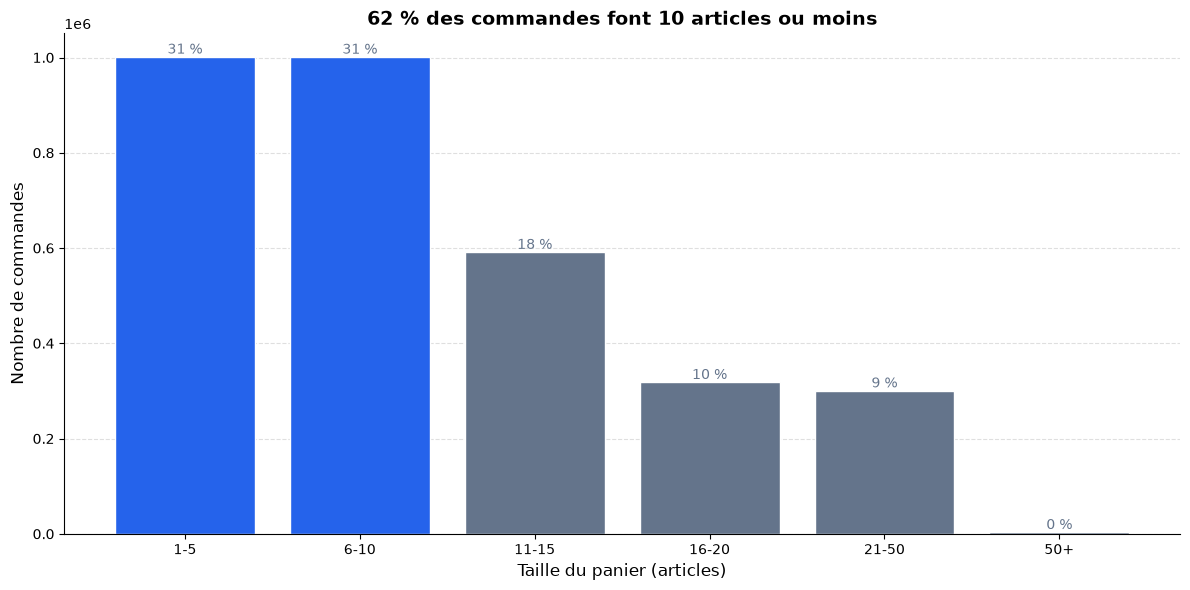

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

bins = [0, 5, 10, 15, 20, 50, 145]
labels = ["1-5", "6-10", "11-15", "16-20", "21-50", "50+"]
basket_groups = pd.cut(basket_sizes["basket_size"], bins=bins, labels=labels)
basket_counts = basket_groups.value_counts().sort_index()
share_le_10 = (basket_sizes["basket_size"] <= 10).mean() * 100

fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = [
    COLORS["bars"],
    COLORS["bars"],
    COLORS["q1"],
    COLORS["q1"],
    COLORS["q1"],
    COLORS["q1"],
]
bars = ax.bar(
    basket_counts.index,
    basket_counts.values,
    color=bar_colors,
    edgecolor="white",
)

total = basket_counts.sum()
for bar, count in zip(bars, basket_counts.values):
    pct = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.0f} %",
        ha="center",
        va="bottom",
        fontsize=10,
        color=COLORS["q1"],
    )

style_chart(
    ax,
    title=f"{share_le_10:.0f} % des commandes font 10 articles ou moins",
    xlabel="Taille du panier (articles)",
    ylabel="Nombre de commandes",
    legend=False,
)

fig.tight_layout()
plt.show()

## Observations

- La moitié des paniers contient **8 articles ou moins** et 62 % en contiennent au plus 10.
- La moyenne est de 10,1 articles, un peu au-dessus de la médiane : quelques très grands paniers tirent cette moyenne vers le haut.

## Recommandation

Le parcours doit rester simple pour les petits paniers, qui représentent la majorité des commandes.

**Actions stratégiques**

- Garantir la disponibilité des produits de base dans les petits paniers.
- Proposer des produits complémentaires lorsque le panier contient peu d'articles.

### Q3. À quel rythme les clients reviennent-ils ?

**Question posée**

Combien de jours séparent deux commandes d'un même client ?

**Méthode**

- Nous étudions le délai entre deux commandes successives.
- La première commande de chaque client est exclue, car elle n'a pas de commande précédente.
- Nous comparons la moyenne, la médiane et les délais élevés pour repérer le rythme habituel et les retours tardifs.

In [38]:
import matplotlib.pyplot as plt

# Exclusion des premières commandes (NaN = pas de délai antérieur)
reorder_delay = df_orders["days_since_prior_order"].dropna()

print(reorder_delay.describe())
print(f"Part à 30 jours : {(reorder_delay == 30).mean() * 100:.1f}%")

count    3.214874e+06
mean     1.111484e+01
std      9.206737e+00
min      0.000000e+00
25%      4.000000e+00
50%      7.000000e+00
75%      1.500000e+01
max      3.000000e+01
Name: days_since_prior_order, dtype: float64
Part à 30 jours : 11.5%


**Résultats clés** : le délai médian est de **7 jours** ; le délai moyen est de 11 jours.

**Visualisation** : les barres regroupent les délais par période afin de voir rapidement la part des clients qui reviennent en une, deux ou trois semaines.

| Statistique | Valeur | Interprétation |
|-------------|--------|----------------|
| Nombre de mesures | 3 214 874 | Délais entre 2 commandes consécutives |
| Moyenne | 11,1 jours | Cycle moyen légèrement supérieur à une semaine |
| Médiane | 7 jours | **Rythme hebdomadaire dominant** |
| Écart-type | 9,2 jours | Dispersion élevée |
| Coefficient de variation | 0,83 | Rythmes d'achat variés |
| Q1 (25%) | 4 jours | Retours rapides |
| Q3 (75%) hors délais censurés | 12 jours | **Seuil statistique de risque** |
| Commandes à 30 j | 11,5 % | Valeur plafonnée par le dataset |
| Minimum | 0 jour | Commande de nouveau le jour même |
| Maximum observé | 30 jours | Plafond imposé par le dataset |

Les délais égaux à 30 jours sont exclus du calcul du Q3 et du graphique principal, car ils peuvent représenter des délais supérieurs censurés. Le seuil opérationnel de relance peut rester fixé à 15 jours pour être plus conservateur.

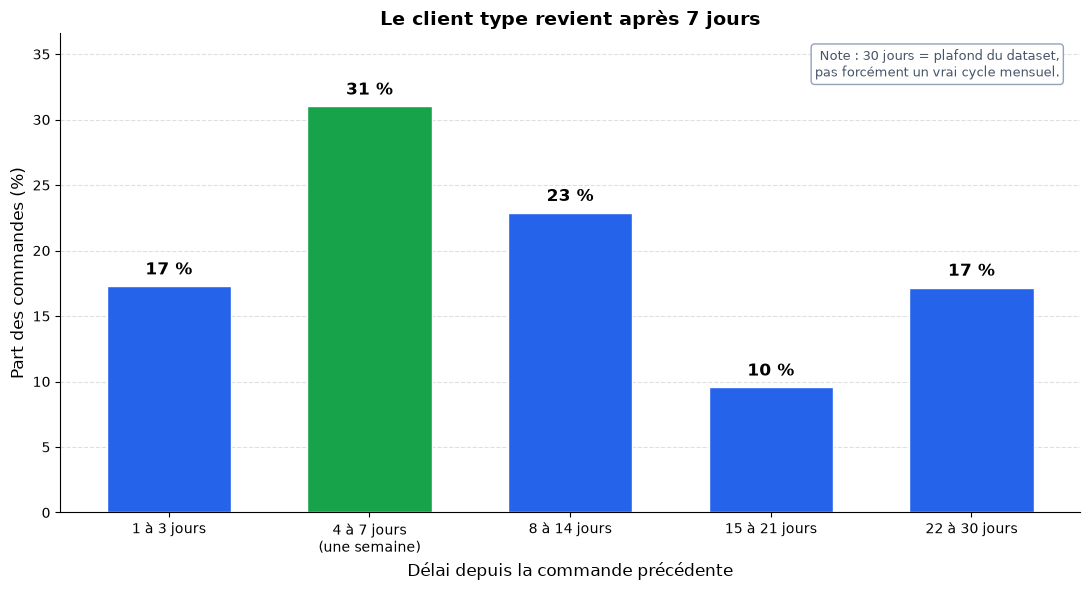

In [39]:
fig, ax = plt.subplots(figsize=(11, 6))

bucket_defs = [
    ("1 à 3 jours", 1, 3),
    ("4 à 7 jours\n(une semaine)", 4, 7),
    ("8 à 14 jours", 8, 14),
    ("15 à 21 jours", 15, 21),
    ("22 à 30 jours", 22, 30),
]
labels = [label for label, _, _ in bucket_defs]
pcts = [reorder_delay.between(lo, hi).mean() * 100 for _, lo, hi in bucket_defs]
bar_colors = [COLORS["bars"]] * len(labels)
bar_colors[1] = COLORS["median"]

bars = ax.bar(labels, pcts, color=bar_colors, edgecolor="white", width=0.62)
for bar, pct in zip(bars, pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f"{pct:.0f} %",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

median_delay = reorder_delay.median()
style_chart(
    ax,
    title=f"Le client type revient après {median_delay:.0f} jours",
    xlabel="Délai depuis la commande précédente",
    ylabel="Part des commandes (%)",
    legend=False,
)
ax.set_ylim(0, max(pcts) * 1.18)
ax.text(
    0.98,
    0.97,
    "Note : 30 jours = plafond du dataset,\npas forcément un vrai cycle mensuel.",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    color=COLORS["annotation"],
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=COLORS["muted"]),
)

fig.tight_layout()
plt.show()


In [40]:
print(f"Revenu à J+7  (médiane)     : {(reorder_delay == 7).mean() * 100:.1f} % des délais")
print(f"Revenu en ≤ 7 jours         : {(reorder_delay <= 7).mean() * 100:.1f} %")
print(f"Revenu en ≤ 14 jours        : {(reorder_delay <= 14).mean() * 100:.1f} %")
print(f"Plafonnés à 30 jours        : {(reorder_delay == 30).mean() * 100:.1f} %")

Revenu à J+7  (médiane)     : 10.0 % des délais
Revenu en ≤ 7 jours         : 50.4 %
Revenu en ≤ 14 jours        : 73.3 %
Plafonnés à 30 jours        : 11.5 %


## Observations

- Le délai habituel est de **7 jours** : environ un client sur deux revient dans la semaine.
- Au-delà de **15 jours**, le retour devient moins habituel. Ce seuil peut servir de signal d'alerte.
- Les délais à 30 jours sont plafonnés par le dataset : ils ne représentent pas forcément un vrai rythme mensuel.

## Recommandation

Adapter les relances au rythme naturel d'achat, qui est principalement hebdomadaire.

**Actions stratégiques**

- Envoyer un rappel de réapprovisionnement autour de J+7.
- Relancer les clients sans commande depuis plus de 15 jours.
- Ne pas créer une campagne spécifique à J+30, car cette valeur est limitée par le dataset.

### Moments et composition des paniers

Nous complétons le portrait général des commandes avec les créneaux d'achat et les rayons les plus présents dans les paniers.

### À quel moment de la semaine les clients commandent-ils ?

**Question posée**

Quels jours et quelles heures concentrent le plus de commandes ?

**Méthode**

Nous comptons les commandes pour chaque combinaison de jour et d'heure.

**Visualisation** : la carte de chaleur permet de repérer rapidement les créneaux les plus actifs.

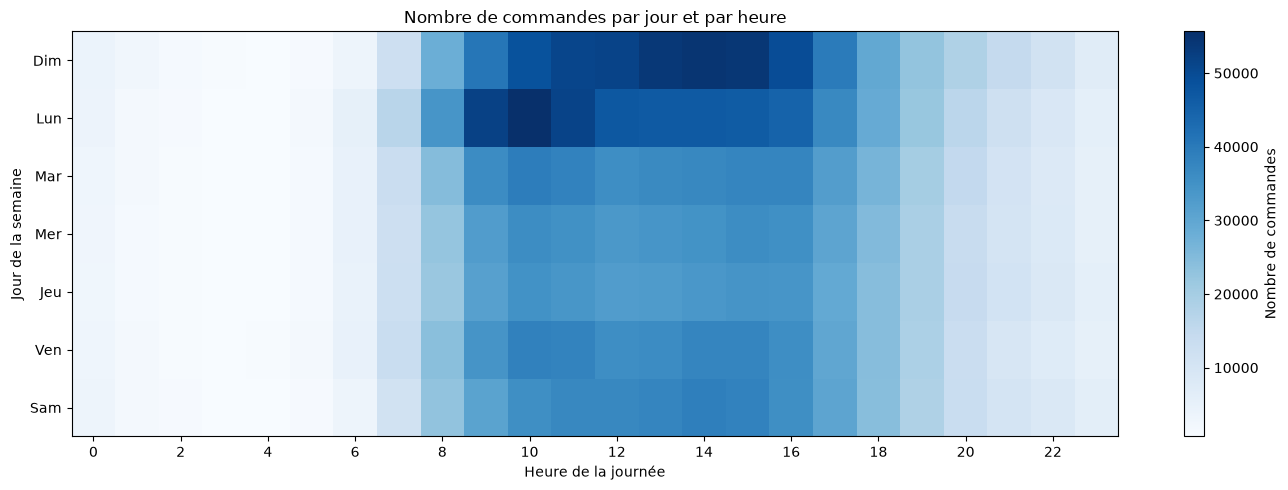

Créneau le plus actif : Lun à 10h


In [41]:
heatmap_data = (
    df_orders.groupby(["order_dow", "order_hour_of_day"])
    .size()
    .reset_index(name="nb_commandes")
    .pivot(index="order_dow", columns="order_hour_of_day", values="nb_commandes")
    .fillna(0)
)
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels(range(0, 24, 2))
ax.set_yticks(range(7))
ax.set_yticklabels(DOW_LABELS)
ax.set_xlabel("Heure de la journée")
ax.set_ylabel("Jour de la semaine")
ax.set_title("Nombre de commandes par jour et par heure")
fig.colorbar(im, ax=ax, label="Nombre de commandes")
plt.tight_layout()
plt.show()
pic = heatmap_data.stack().idxmax()
print(f"Créneau le plus actif : {DOW_LABELS[pic[0]]} à {pic[1]}h")


## Observations

Certaines périodes de la semaine et de la journée regroupent davantage de commandes que d'autres.

## Recommandation

Utiliser ces créneaux pour organiser les opérations et les communications.

**Actions stratégiques**

- Renforcer les capacités de préparation et de livraison sur les créneaux les plus actifs.
- Planifier les communications commerciales en dehors de ces périodes pour mieux répartir la demande.

### Quels rayons remplissent le plus le panier ?

**Question posée**

Dans quels rayons les clients achètent-ils le plus d'articles au cours d'une même commande ?

**Méthode**

Nous comparons la quantité d'articles achetés par commande dans les 10 rayons les plus fréquents.

**Visualisation** : les barres indiquent la quantité médiane d'articles par rayon. Les intervalles représentent la dispersion habituelle entre le premier et le troisième quartile.

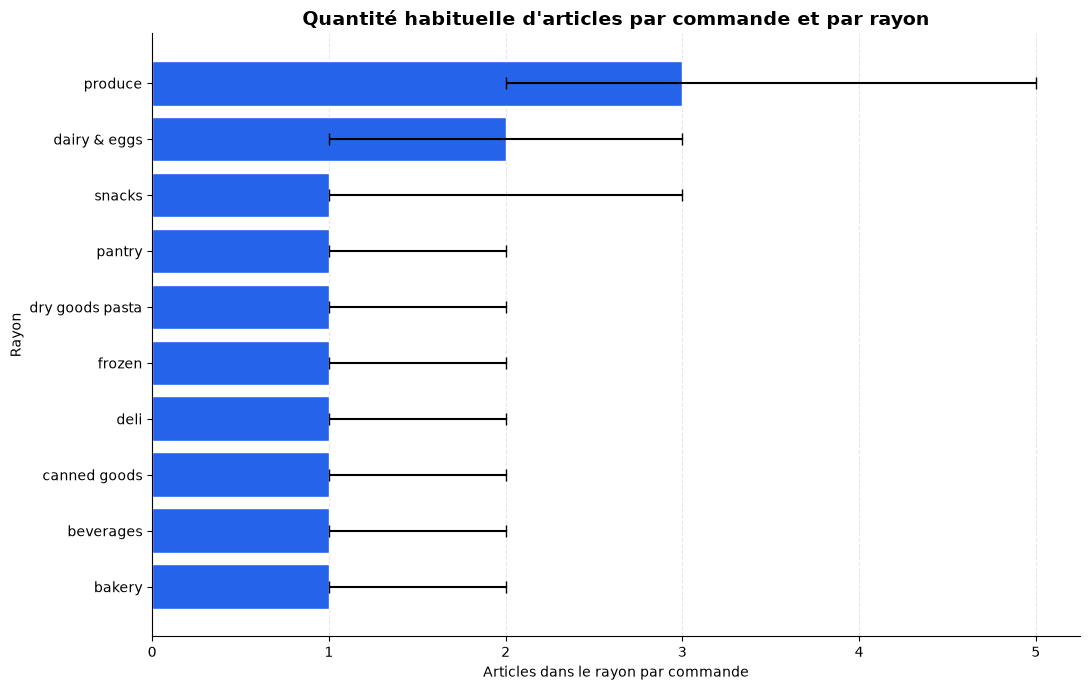

In [77]:
departments = load_departments()
articles = df_full_analysis.merge(departments, on="department_id", how="left")
top_depts = articles["department"].value_counts().head(10).index.tolist()
subset = articles[articles["department"].isin(top_depts)]
panier_par_rayon = (
    subset.groupby(["order_id", "department"])
    .size()
    .reset_index(name="articles_dans_rayon")
)

resume_rayons = (
    panier_par_rayon
    .groupby("department")["articles_dans_rayon"]
    .agg(
        mediane="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
    )
    .sort_values("mediane", ascending=True)
)
resume_rayons["erreur_basse"] = resume_rayons["mediane"] - resume_rayons["q1"]
resume_rayons["erreur_haute"] = resume_rayons["q3"] - resume_rayons["mediane"]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(
    resume_rayons.index,
    resume_rayons["mediane"],
    xerr=[
        resume_rayons["erreur_basse"],
        resume_rayons["erreur_haute"],
    ],
    color=COLORS["primary"],
    edgecolor="white",
    capsize=4,
)

ax.set_title(
    "Quantité habituelle d'articles par commande et par rayon",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Articles dans le rayon par commande")
ax.set_ylabel("Rayon")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()


## Observations

Les produits frais et l'épicerie font partie des rayons qui apportent le plus d'articles par commande.

## Recommandation

Utiliser le contenu du panier pour proposer des produits complémentaires cohérents.

**Actions stratégiques**

- Suggérer des produits associés au rayon principal du panier.
- Créer des offres groupées simples pour les rayons souvent achetés ensemble.

---

## Synthèse du Bloc A

- Le client type passe environ **10 commandes**, avec un panier médian de **8 articles**.
- Il revient généralement au bout de **7 jours**.
- Les achats sont donc souvent de petits réapprovisionnements réguliers.

## Recommandations

- Mettre en avant les produits de base et leur disponibilité.
- Envoyer des rappels autour de J+7.
- Adapter les offres aux petits paniers, qui sont les plus fréquents.

---

## Bloc B : Comment le client change au fil de ses commandes

Le Bloc A a décrit les clients à un instant donné. Ici on pose une autre question :
**est-ce que ce portrait bouge quand le client accumule les commandes ?**

La colonne `order_number` donne le numéro de chaque commande dans la vie du client
(1 = sa première). En regroupant toutes les commandes par ce numéro, on obtient le
comportement moyen d'un client à sa 1re commande, à sa 10e, à sa 30e.

Deux précautions valables pour tout le bloc :

- Ces questions portent sur des commandes, pas sur des articles. On regroupe donc
  les articles par commande avant toute analyse.
- Plus le numéro de commande est élevé, moins il reste de clients concernés. Les
  moyennes deviennent peu fiables sur la fin : il faudra s'arrêter avant.

### Préparation du Bloc B

On regroupe les articles par commande avec `build_order_level_view`.


### Jusqu'où peut-on aller ?

Tous les clients n'ont pas passé le même nombre de commandes. À la 90e, il n'en reste
qu'une poignée : une moyenne calculée sur si peu de monde ne veut plus rien dire.

On s'arrête donc au dernier numéro de commande pour lequel **au moins 5 % des clients
sont encore là**. Tous les graphiques du bloc s'arrêteront à cette limite.

In [43]:
nb_clients_par_rang = df_commandes["order_number"].value_counts().sort_index()
nb_clients = df_commandes["user_id"].nunique()

LIMITE = nb_clients_par_rang[nb_clients_par_rang >= 0.05 * nb_clients].index.max()

print(f"Numéro de commande le plus élevé : {df_commandes['order_number'].max()}")
print(f"Limite retenue : {LIMITE} commandes "
      f"({nb_clients_par_rang[LIMITE]:,} clients, soit {nb_clients_par_rang[LIMITE]/nb_clients:.1%})")

Numéro de commande le plus élevé : 99
Limite retenue : 51 commandes (10,328 clients, soit 5.0%)


---

### Q4. La taille du panier change-t-elle au fil des commandes ?

**Question posée**

Un client fidèle achète-t-il davantage d'articles à chaque commande ?

**Méthode**

- Nous comparons la taille médiane des paniers selon le numéro de commande.
- L'analyse s'arrête lorsque le nombre de clients devient trop faible pour être représentatif.

**Visualisation** : les barres permettent de voir immédiatement si les paniers grandissent avec le temps.

In [44]:
df_orders_analysis = (
    df_orders[["order_id", "user_id", "order_number"]]
    .merge(basket_sizes, on="order_id", how="inner")
)
n_orders = df_orders_analysis.groupby("user_id")["order_id"].transform("nunique")
df_cohorte = df_orders_analysis[n_orders >= 15]
df_analyse = df_cohorte[df_cohorte["order_number"] <= 15].copy()
evolution_basket = df_analyse.groupby("order_number")["basket_size"].mean()
print("Panier moyen par rang (1 à 15) :")
for rank in (1, 5, 10, 15):
    if rank in evolution_basket.index:
        print(f"  {rank}e commande : {evolution_basket.loc[rank]:.2f} articles")


Panier moyen par rang (1 à 15) :
  1e commande : 10.64 articles
  5e commande : 10.22 articles
  10e commande : 10.06 articles
  15e commande : 10.12 articles


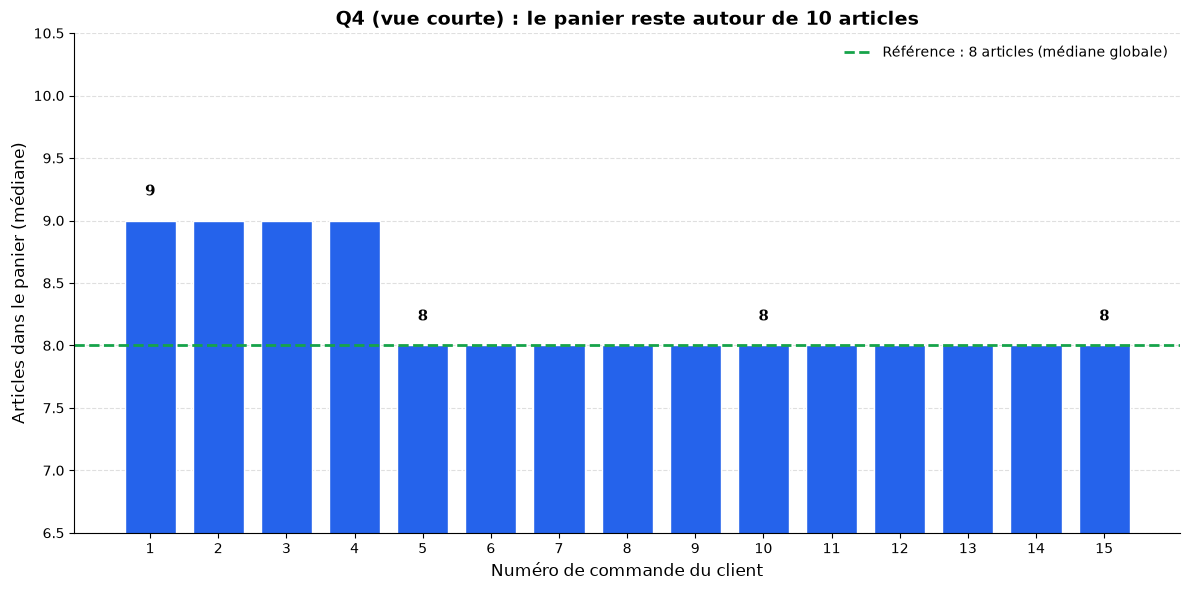

In [45]:
stats = df_analyse.groupby("order_number")["basket_size"].median()
rangs = list(range(1, 16))
medians = [stats.get(r) for r in rangs]
ref = df_analyse["basket_size"].median()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(rangs, medians, color=COLORS["bars"], edgecolor="white", width=0.75)
ax.axhline(
    ref,
    color=COLORS["median"],
    linestyle="--",
    linewidth=2,
    label=f"Référence : {ref:.0f} articles (médiane globale)",
)
for rank in (1, 5, 10, 15):
    if rank in stats.index:
        ax.text(rank, stats[rank] + 0.2, f"{stats[rank]:.0f}", ha="center", fontsize=11, fontweight="bold")

style_chart(
    ax,
    title="Q4 (vue courte) : le panier reste autour de 10 articles",
    xlabel="Numéro de commande du client",
    ylabel="Articles dans le panier (médiane)",
)
ax.set_xticks(rangs)
ax.set_ylim(min(medians) - 1.5, max(medians) + 1.5)
plt.tight_layout()
plt.show()


In [46]:
evolution_panier = df_commandes.groupby("order_number")["basket_size"].mean()

print(evolution_panier.reindex([1, 2, 5, 10, 20, 30, 50]).round(2))
print(f"\nDu plus petit au plus grand sur les {LIMITE} premières commandes : "
      f"{evolution_panier.loc[:LIMITE].min():.2f} à {evolution_panier.loc[:LIMITE].max():.2f} articles")

order_number
1     10.08
2      9.93
5     10.01
10    10.12
20    10.15
30    10.30
50    10.17
Name: basket_size, dtype: float64

Du plus petit au plus grand sur les 51 premières commandes : 9.93 à 10.40 articles


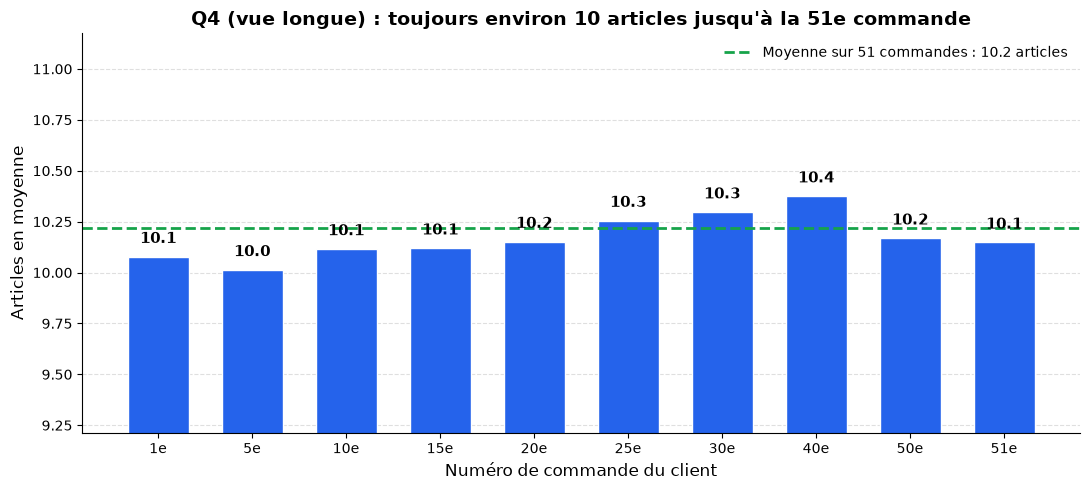

In [47]:
rangs_cles = [r for r in [1, 5, 10, 15, 20, 25, 30, 40, 50] if r <= LIMITE]
if LIMITE not in rangs_cles:
    rangs_cles.append(LIMITE)

moyennes = [evolution_panier.loc[r] for r in rangs_cles]
moyenne_bloc = evolution_panier.loc[:LIMITE].mean()

fig, ax = plt.subplots(figsize=(11, 5))
x_labels = [f"{r}e" for r in rangs_cles]
bars = ax.bar(x_labels, moyennes, color=COLORS["bars"], edgecolor="white", width=0.65)
ax.axhline(
    moyenne_bloc,
    color=COLORS["median"],
    linestyle="--",
    linewidth=2,
    label=f"Moyenne sur {LIMITE} commandes : {moyenne_bloc:.1f} articles",
)
for bar, val in zip(bars, moyennes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{val:.1f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

style_chart(
    ax,
    title=f"Q4 (vue longue) : toujours environ {moyenne_bloc:.0f} articles jusqu'à la {LIMITE}e commande",
    xlabel="Numéro de commande du client",
    ylabel="Articles en moyenne",
)
ax.set_ylim(min(moyennes) - 0.8, max(moyennes) + 0.8)
plt.tight_layout()
plt.show()


## Observations

- Le panier reste proche de **10 articles** de la première à la trentième commande.
- La fidélité ne vient donc pas d'un panier plus grand, mais d'achats plus réguliers.

## Recommandation

Prioriser la fréquence de commande plutôt que la hausse systématique du nombre d'articles par panier.

**Actions stratégiques**

- Proposer des rappels ou suggestions de réachat entre deux commandes.
- Réserver les offres d'augmentation de panier aux clients pour qui elles sont pertinentes.

---

### Q5. Le délai entre commandes se raccourcit-il ?

**Question posée**

Les clients fidèles commandent-ils plus souvent au fil du temps ?

**Méthode**

- Nous calculons le délai moyen entre deux commandes pour chaque numéro de commande.
- Nous observons son évolution jusqu'à la limite retenue pour le Bloc B.

**Visualisation** : la courbe montre si le délai diminue ou augmente avec l'expérience du client.

In [48]:
evolution_delai = df_commandes.groupby("order_number")["days_since_prior_order"].mean()

print(evolution_delai.reindex([2, 3, 5, 10, 20, 30, 50]).round(1))
print(f"\nDe {evolution_delai.loc[2]:.1f} à {evolution_delai.loc[50]:.1f} jours (50e commande), "
      f"soit {(evolution_delai.loc[50]/evolution_delai.loc[2]-1):.0%}")

order_number
2     15.3
3     15.3
5     14.1
10    11.8
20     8.9
30     7.1
50     5.1
Name: days_since_prior_order, dtype: float64

De 15.3 à 5.1 jours (50e commande), soit -67%


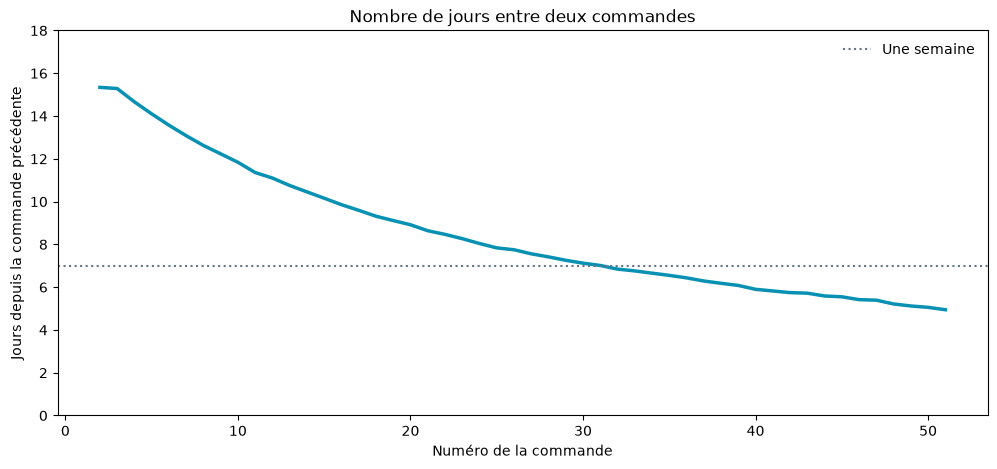

In [49]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    evolution_delai.loc[:LIMITE].index,
    evolution_delai.loc[:LIMITE].values,
    color=COLORS["secondary"],
    linewidth=2.5,
)
ax.axhline(7, color=COLORS["neutral"], linestyle=":", linewidth=1.5, label="Une semaine")
ax.set_ylim(0, 18)
ax.set_title("Nombre de jours entre deux commandes")
ax.set_xlabel("Numéro de la commande")
ax.set_ylabel("Jours depuis la commande précédente")
ax.legend(frameon=False)
plt.show()


## Observations

- Le délai moyen passe de **15,3 jours** entre les premières commandes à **5,1 jours** à la 50e commande.
- Plus un client commande, plus il revient vite. C'est le changement le plus net observé avec la fidélité.

## Recommandation

La fidélité se construit surtout par la fréquence d'achat, pas par des paniers plus grands.

**Actions stratégiques**

- Adapter les rappels au rythme de chaque client.
- Valoriser les commandes régulières avec des avantages simples.

---

### Q6. La part de produits déjà connus augmente-t-elle ?

**Question posée**

Les clients rachètent-ils davantage les mêmes produits au fil des commandes ?

**Méthode**

- Pour chaque commande, nous calculons la part de produits déjà achetés auparavant.
- Nous suivons cette part selon le numéro de commande et à plusieurs moments du parcours client.

**Visualisation** : la courbe montre l'évolution globale ; les graphiques circulaires illustrent quelques étapes clés.

In [50]:
evolution_reachat = df_commandes.groupby("order_number")["reorder_share"].mean()

print((evolution_reachat.reindex([1, 2, 3, 5, 10, 20, 30, 50]) * 100).round(1))

# Ce que chaque commande supplémentaire fait gagner (sert à la Q7)
gain_reachat = evolution_reachat.diff() * 100
print("\nGain apporté par chaque commande (en points) :")
print(gain_reachat.loc[2:15].round(2).to_string())

order_number
1      0.0
2     28.8
3     40.5
5     52.6
10    65.0
20    74.5
30    78.2
50    81.7
Name: reorder_share, dtype: float64

Gain apporté par chaque commande (en points) :
order_number
2     28.84
3     11.68
4      7.20
5      4.88
6      3.59
7      2.97
8      2.21
9      2.03
10     1.60
11     1.46
12     1.41
13     1.04
14     1.19
15     0.85


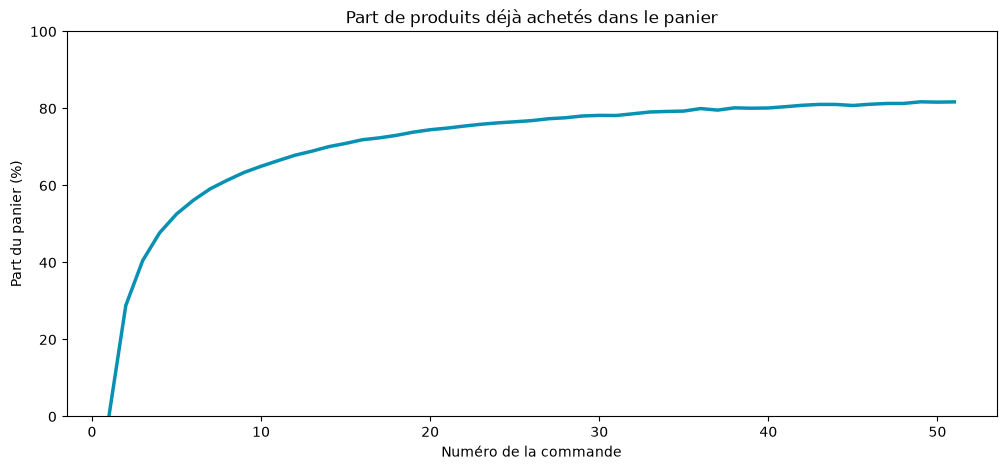

In [51]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    evolution_reachat.loc[:LIMITE].index,
    evolution_reachat.loc[:LIMITE].values * 100,
    color=COLORS["secondary"],
    linewidth=2.5,
)
ax.set_ylim(0, 100)
ax.set_title("Part de produits déjà achetés dans le panier")
ax.set_xlabel("Numéro de la commande")
ax.set_ylabel("Part du panier (%)")
plt.show()


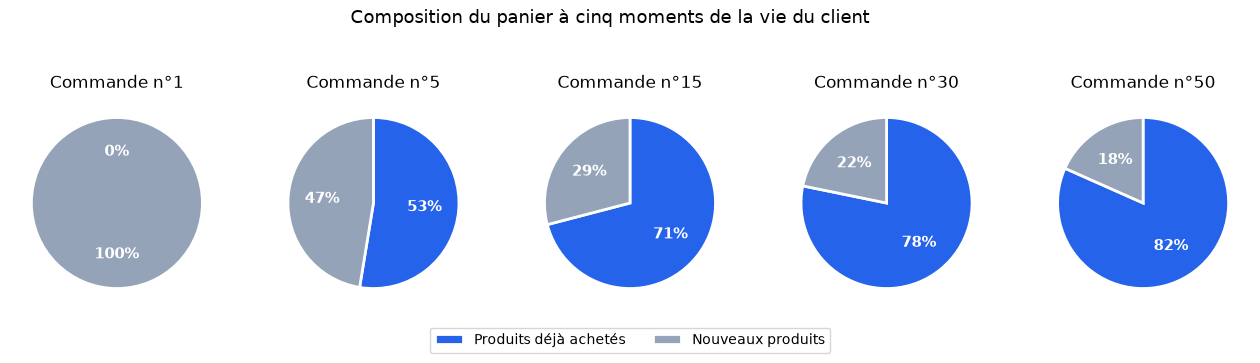

In [52]:
moments = [1, 5, 15, 30, 50]

fig, axes = plt.subplots(1, len(moments), figsize=(16, 4))

for ax, rang in zip(axes, moments):
    part_connus = evolution_reachat.loc[rang] * 100
    ax.pie(
        [part_connus, 100 - part_connus],e
        colors=[COLORS["primary"], COLORS["muted"]],
        autopct="%1.0f%%",
        startangle=90,
        counterclock=False,
        textprops=dict(color="white", fontweight="bold", fontsize=11),
        wedgeprops=dict(edgecolor="white", linewidth=2),
    )
    ax.set_title(f"Commande n°{rang}", fontsize=12)

axes[0].legend(
    ["Produits déjà achetés", "Nouveaux produits"],
    loc="upper center",
    bbox_to_anchor=(2.9, -0.05),
    ncol=2,
)
fig.suptitle("Composition du panier à cinq moments de la vie du client", fontsize=13)
plt.show()


## Observations

- La part de produits déjà connus passe de 0 % à la première commande à **53 % dès la 5e**, puis à **82 % à la 50e**.
- L'habitude se crée donc rapidement, mais le client continue aussi à découvrir de nouveaux produits.

## Recommandation

Personnaliser les suggestions très tôt, en s'appuyant sur les premiers produits achetés.

**Actions stratégiques**

- Dès la deuxième commande, mettre en avant les produits déjà achetés.
- Conserver quelques suggestions de découverte pour éviter un panier trop répétitif.

---

### Q7. À partir de quelle commande le comportement se stabilise-t-il ?

**Question posée**

À quel moment les habitudes d'achat cessent-elles de changer fortement ?

**Méthode**

- Nous mesurons le gain apporté par chaque commande à la part de produits déjà connus.
- La stabilisation commence lorsque ce gain devient inférieur à un point de pourcentage.

**Visualisation** : les barres montrent ce que chaque nouvelle commande ajoute à l'habitude d'achat.

In [53]:
stabilisation = gain_reachat[gain_reachat < 1].index.min()

print(f"Le comportement se stabilise à la commande n°{stabilisation}")
print(f"  part de produits connus : {evolution_reachat.loc[stabilisation]:.1%}")
print(f"  délai entre commandes   : {evolution_delai.loc[stabilisation]:.1f} jours")
print(f"  taille du panier        : {evolution_panier.loc[stabilisation]:.1f} articles")
print(f"\nGagné sur les {stabilisation} premières commandes : "
      f"{evolution_reachat.loc[stabilisation]*100:.0f} points")
print(f"Gagné sur les {LIMITE - stabilisation} suivantes : "
      f"{(evolution_reachat.loc[LIMITE]-evolution_reachat.loc[stabilisation])*100:.0f} points")

Le comportement se stabilise à la commande n°15
  part de produits connus : 70.9%
  délai entre commandes   : 10.2 jours
  taille du panier        : 10.1 articles

Gagné sur les 15 premières commandes : 71 points
Gagné sur les 36 suivantes : 11 points


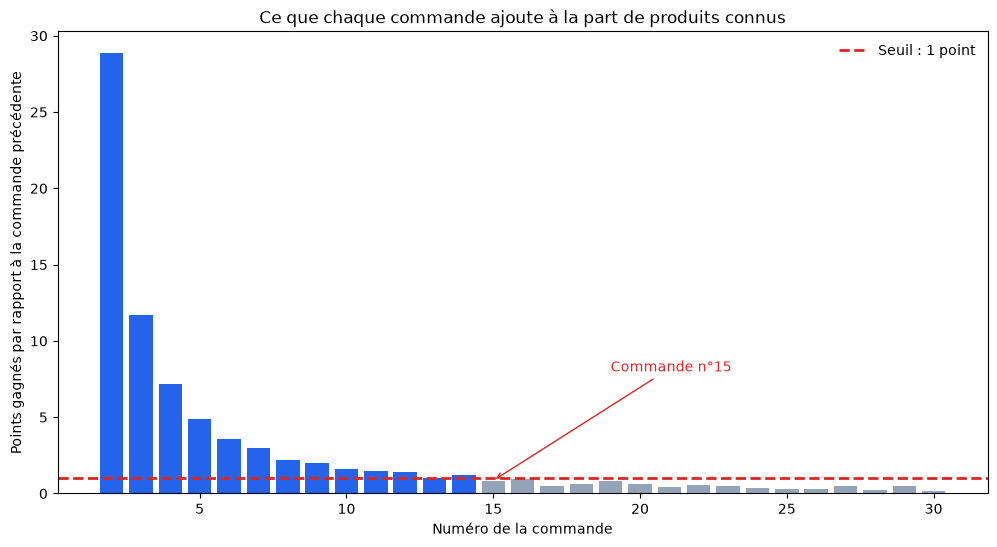

In [54]:
gains = gain_reachat.loc[2:30]
couleurs = [COLORS["primary"] if gain >= 1 else COLORS["muted"] for gain in gains]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(gains.index, gains.values, color=couleurs)
ax.axhline(1, color=COLORS["negative"], linestyle="--", linewidth=2, label="Seuil : 1 point")
ax.annotate(
    f"Commande n°{stabilisation}",
    xy=(stabilisation, gains.loc[stabilisation]),
    xytext=(stabilisation + 4, 8),
    arrowprops=dict(arrowstyle="->", color=COLORS["negative"]),
    color=COLORS["negative"],
)

ax.set_title("Ce que chaque commande ajoute à la part de produits connus")
ax.set_xlabel("Numéro de la commande")
ax.set_ylabel("Points gagnés par rapport à la commande précédente")
ax.legend(frameon=False)
plt.show()


## Observations

- Le gain de nouveaux produits connus devient faible à partir de la **15e commande**.
- À ce stade, le client achète déjà environ 71 % de produits qu'il connaît. La taille du panier, elle, était stable dès le début ; la fréquence continue de progresser.

## Recommandation

Les premières commandes sont le meilleur moment pour aider le client à construire ses habitudes.

**Actions stratégiques**

- Accompagner davantage les 5 premières commandes avec des suggestions simples.
- Maintenir des recommandations personnalisées jusqu'à la 15e commande.

---

### Q8. Le premier panier ressemble-t-il aux suivants ?

**Question posée**

La première commande permet-elle déjà de comprendre les préférences d'un client ?

**Méthode**

- Nous comparons la part des articles achetés dans chaque rayon entre la première commande et les suivantes.
- Nous regardons les rayons les plus fréquents et l'écart entre les deux périodes.

**Visualisation** : les barres comparent les principales catégories du premier panier avec celles des commandes suivantes.

In [55]:
departments = load_departments()
articles = df_full_analysis.merge(departments, on="department_id", how="left")

premiere = articles[articles["order_number"] == 1]["department"].value_counts(normalize=True) * 100
suivantes = articles[articles["order_number"] > 1]["department"].value_counts(normalize=True) * 100

comparaison = pd.DataFrame({"1re commande": premiere, "Commandes suivantes": suivantes})
comparaison["écart"] = comparaison["1re commande"] - comparaison["Commandes suivantes"]
comparaison = comparaison.sort_values("1re commande", ascending=False)

print(comparaison.head(10).round(2).to_string())
print(f"\nPlus gros écart constaté : {comparaison['écart'].abs().max():.2f} point")

                 1re commande  Commandes suivantes  écart
department                                               
produce                 28.12                29.30  -1.18
dairy & eggs            16.03                16.74  -0.71
snacks                   8.71                 8.92  -0.21
beverages                8.07                 8.31  -0.24
frozen                   7.62                 6.85   0.77
pantry                   6.17                 5.76   0.42
bakery                   3.64                 3.63   0.01
canned goods             3.55                 3.28   0.27
deli                     3.37                 3.23   0.14
dry goods pasta          2.93                 2.65   0.28

Plus gros écart constaté : 1.18 point


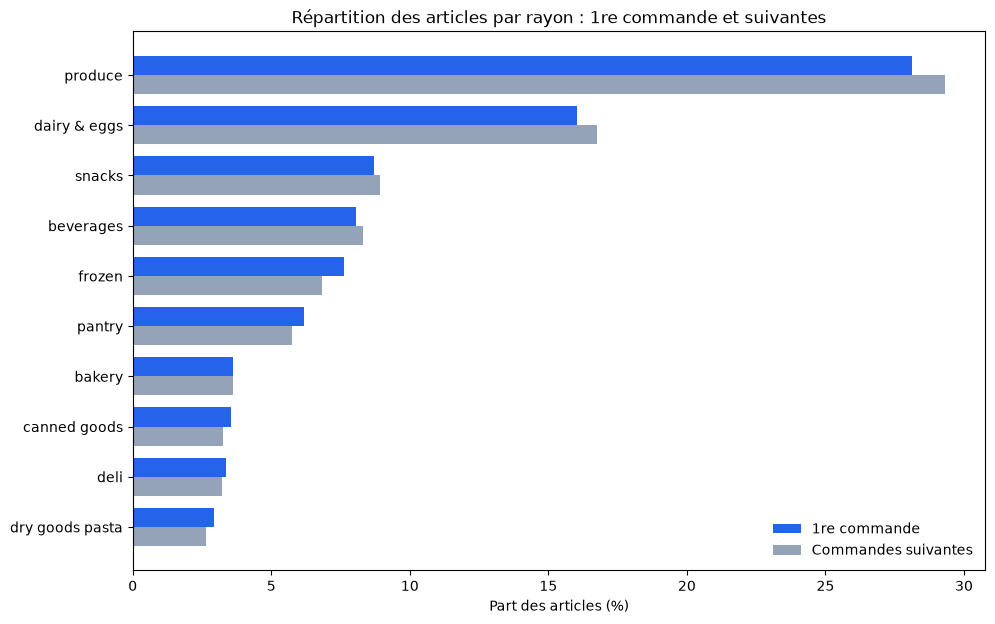

In [56]:
top = comparaison.head(10).iloc[::-1]
positions = np.arange(len(top))
epaisseur = 0.38

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(
    positions + epaisseur / 2,
    top["1re commande"],
    height=epaisseur,
    color=COLORS["primary"],
    label="1re commande",
)
ax.barh(
    positions - epaisseur / 2,
    top["Commandes suivantes"],
    height=epaisseur,
    color=COLORS["muted"],
    label="Commandes suivantes",
)

ax.set_yticks(positions)
ax.set_yticklabels(top.index)
ax.set_title("Répartition des articles par rayon : 1re commande et suivantes")
ax.set_xlabel("Part des articles (%)")
ax.legend(frameon=False)
plt.show()
e

## Observations

- La première commande ressemble déjà beaucoup aux suivantes : le plus grand écart entre les principaux rayons est de seulement **1,2 point**.
- Les fruits et légumes, les produits laitiers et les surgelés gardent une part très proche d'une commande à l'autre.

## Recommandation

Les préférences du client peuvent être utilisées dès sa première commande.

**Actions stratégiques**

- Proposer rapidement des recommandations adaptées au premier panier.
- Utiliser les rayons déjà achetés pour suggérer les produits complémentaires.

---

## Synthèse du Bloc B

- La taille du panier et sa composition changent peu avec le temps.
- En revanche, les clients commandent de plus en plus souvent et rachètent davantage les mêmes produits.
- Les habitudes se construisent surtout pendant les **5 à 15 premières commandes**.

## Recommandations

- Personnaliser les suggestions dès le premier panier.
- Encourager les premières commandes régulières avec des avantages progressifs.
- Mettre l'accent sur les produits déjà achetés tout en gardant une part de découverte.

---

## Bloc C : Transformer l'analyse en actions

Nous utilisons maintenant les résultats précédents pour mieux fidéliser les clients : identifier ceux qui pèsent le plus, comprendre leurs habitudes et repérer les signaux d'alerte.

### Segments utilisés

- **Nouveaux** : jusqu'à 5 commandes.
- **Transitionnels** : de 6 à 24 commandes.
- **Fidèles** : 25 commandes ou plus.

Nous comparons ces segments selon leur volume d'achat, leurs rayons préférés, leurs horaires et leur rythme de retour.

In [57]:
# Préparation des segments pour le Bloc C
# Les segments sont définis au niveau des ARTICLES dans df_full_analysis

SEGMENT_NEW_MAX = 5  # Nouveaux clients : <= 5 commandes
SEGMENT_LOYAL_MIN = 25  # Clients fidèles : >= 25 commandes

# Ajouter une colonne "segment" à df_full_analysis
df_full_analysis['segment'] = pd.cut(
    df_full_analysis['order_number'],
    bins=[0, SEGMENT_NEW_MAX, SEGMENT_LOYAL_MIN, float('inf')],
    labels=['Nouveaux', 'Transitionnels', 'Fidèles'],
    include_lowest=True
)

# Compter les observations par segment
print("Distribution des articles par segment client:")
print(df_full_analysis['segment'].value_counts().sort_index())

# Au niveau client : chaque client est classé selon son nombre total de commandes
client_max_order = df_full_analysis.groupby('user_id')['order_number'].max()
client_segments = pd.cut(
    client_max_order,
    bins=[0, SEGMENT_NEW_MAX, SEGMENT_LOYAL_MIN, float('inf')],
    labels=['Nouveaux', 'Transitionnels', 'Fidèles'],
    include_lowest=True
)
print("\nNombre de clients par segment:")
print(client_segments.value_counts().sort_index())

# Au niveau commandes
orders_by_segment = df_full_analysis.groupby('order_id')['segment'].first().reset_index()
orders_segment_counts = orders_by_segment['segment'].value_counts()
print("\nNombre de commandes par segment:")
print(orders_segment_counts)


Distribution des articles par segment client:
segment
Nouveaux           9625840
Transitionnels    15405310
Fidèles            7403339
Name: count, dtype: int64

Nombre de clients par segment:
order_number
Nouveaux           59741
Transitionnels    110503
Fidèles            35965
Name: count, dtype: int64

Nombre de commandes par segment:
segment
Transitionnels    1520985
Nouveaux           963483
Fidèles            730406
Name: count, dtype: int64


---

### Q9. Quelle part du volume les clients fidèles représentent-ils ?

**Question posée**

Les clients fidèles pèsent-ils davantage dans l'activité que leur nombre ne le laisse penser ?

**Méthode**

- Nous comparons la part de clients, de commandes et d'articles de chaque segment.
- Le volume correspond au nombre d'articles achetés, car le dataset ne contient pas de prix.

**Visualisation** : les barres montrent la part de chaque segment ; le graphique à jalons montre la concentration du volume chez les clients les plus actifs.

In [58]:
# Q9 : Vérifications avant graphique
print("="*60)
print("Q9 : Quelle part du volume les fidèles représentent-ils ?")
print("="*60)

# Vérifier les colonnes nécessaires
required_cols = ['user_id', 'order_id', 'order_number', 'segment']
assert all(col in df_full_analysis.columns for col in required_cols), "Colonnes manquantes"
print("✓ Colonnes vérifiées")

# Vérifier la segmentation
print("\n✓ Distribution des segments :")
print(df_full_analysis['segment'].value_counts(dropna=False))

# Part des CLIENTS : chaque client est classé selon son nombre total de commandes
share_clients = client_segments.value_counts(normalize=True) * 100

print("\n✓ Part des clients :")
print(share_clients.sort_index())

# Part des COMMANDES
unique_orders_by_seg = df_full_analysis.drop_duplicates(subset=['order_id'])
share_orders = unique_orders_by_seg['segment'].value_counts(normalize=True) * 100

print("\n✓ Part des commandes :")
print(share_orders.sort_index())

# Part des ARTICLES
share_articles = df_full_analysis['segment'].value_counts(normalize=True) * 100

print("\n✓ Part des articles (volume) :")
print(share_articles.sort_index())

# Résumé pour comparaison
q9_summary = pd.DataFrame({
    'Nouveaux': [
        share_clients.get('Nouveaux', 0),
        share_orders.get('Nouveaux', 0),
        share_articles.get('Nouveaux', 0)
    ],
    'Transitionnels': [
        share_clients.get('Transitionnels', 0),
        share_orders.get('Transitionnels', 0),
        share_articles.get('Transitionnels', 0)
    ],
    'Fidèles': [
        share_clients.get('Fidèles', 0),
        share_orders.get('Fidèles', 0),
        share_articles.get('Fidèles', 0)
    ]
}, index=['Clients (%)', 'Commandes (%)', 'Articles (%)'])

print("\n" + "="*60)
print("RÉSUMÉ Q9 - Part par segment")
print("="*60)
print(q9_summary.round(1))


Q9 : Quelle part du volume les fidèles représentent-ils ?
✓ Colonnes vérifiées

✓ Distribution des segments :
segment
Transitionnels    15405310
Nouveaux           9625840
Fidèles            7403339
Name: count, dtype: int64

✓ Part des clients :
order_number
Nouveaux          28.971092
Transitionnels    53.587865
Fidèles           17.441043
Name: proportion, dtype: float64

✓ Part des commandes :
segment
Nouveaux          29.969542
Transitionnels    47.310874
Fidèles           22.719584
Name: proportion, dtype: float64

✓ Part des articles (volume) :
segment
Nouveaux          29.677791
Transitionnels    47.496694
Fidèles           22.825515
Name: proportion, dtype: float64

RÉSUMÉ Q9 - Part par segment
               Nouveaux  Transitionnels  Fidèles
Clients (%)        29.0            53.6     17.4
Commandes (%)      30.0            47.3     22.7
Articles (%)       29.7            47.5     22.8


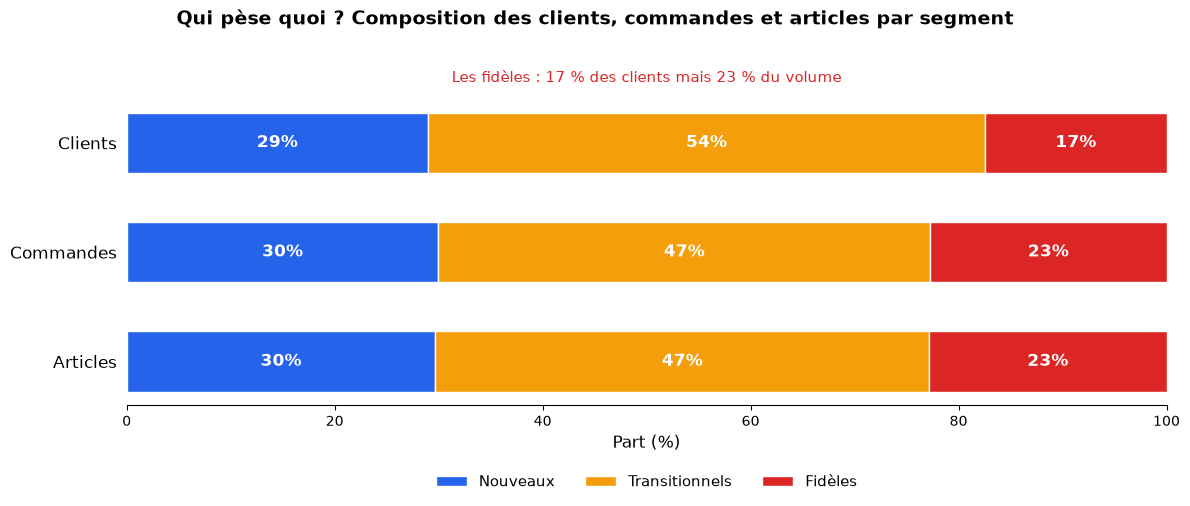

In [59]:
# Q9 Graphique 1 : Composition de chaque métrique par segment (barres empilées 100 %)
# Lecture : si la bande "Fidèles" est plus large en Articles qu'en Clients,
# c'est que chaque fidèle pèse plus lourd que sa part de clients.

fig, ax = plt.subplots(figsize=(12, 5.5))

categories = ['Clients', 'Commandes', 'Articles']
data_order = ['Nouveaux', 'Transitionnels', 'Fidèles']
colors_seg = {
    'Nouveaux': COLORS["segment_new"],
    'Transitionnels': COLORS["segment_transition"],
    'Fidèles': COLORS["segment_loyal"],
}

# Matrice : lignes = métriques, colonnes = segments
values_by_metric = {
    'Clients': [share_clients.get(s, 0) for s in data_order],
    'Commandes': [share_orders.get(s, 0) for s in data_order],
    'Articles': [share_articles.get(s, 0) for s in data_order],
}

y_pos = np.arange(len(categories))
left = np.zeros(len(categories))

for i, segment in enumerate(data_order):
    seg_values = np.array([values_by_metric[cat][i] for cat in categories])
    ax.barh(
        y_pos,
        seg_values,
        left=left,
        height=0.55,
        label=segment,
        color=colors_seg[segment],
        edgecolor='white',
    )
    for y, (value, start) in enumerate(zip(seg_values, left)):
        ax.text(
            start + value / 2,
            y,
            f'{value:.0f}%',
            ha='center',
            va='center',
            fontsize=12,
            fontweight='bold',
            color='white',
        )
    left += seg_values

ax.set_yticks(y_pos)
ax.set_yticklabels(categories, fontsize=12)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel('Part (%)', fontsize=12)
fig.suptitle(
    'Qui pèse quoi ? Composition des clients, commandes et articles par segment',
    fontsize=14,
    fontweight='bold',
    y=0.98,
)
ax.set_title(
    "Les fidèles : 17 % des clients mais 23 % du volume",
    fontsize=11,
    color=COLORS["negative"],
    pad=12,
)
ax.legend(frameon=False, fontsize=11, loc='lower center', bbox_to_anchor=(0.5, -0.32), ncol=3)
for spine in ('top', 'right', 'left'):
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


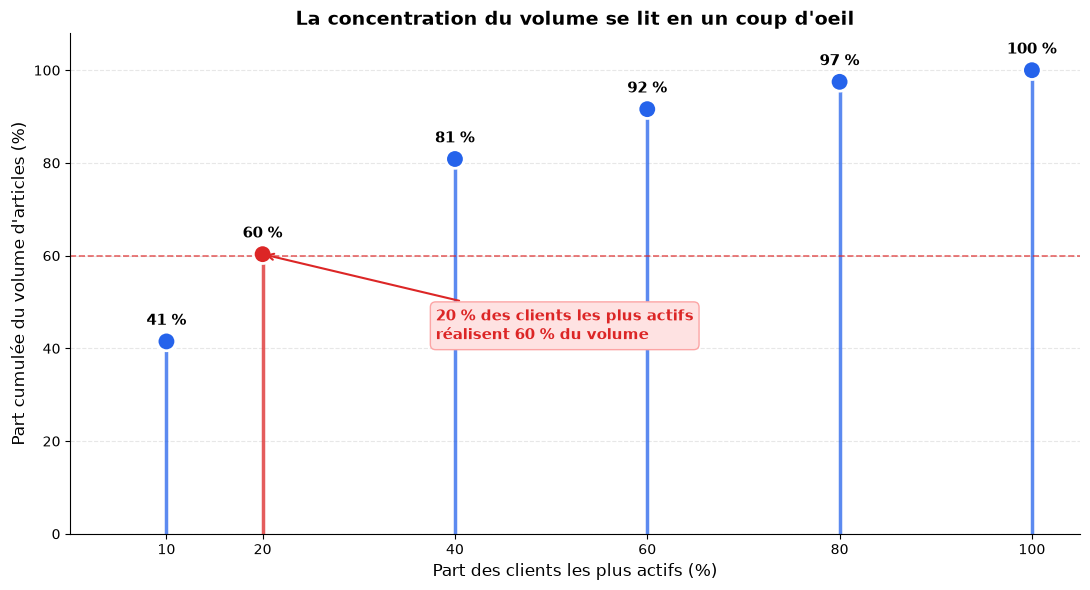

Concentration du volume :
  -> 20 % des clients génèrent 60 % du volume


In [60]:
# Q9 Graphique 2 : Concentration du volume par jalons
# Chaque point répond directement : quelle part du volume les clients les plus actifs créent-ils ?

client_orders = df_full_analysis.groupby('user_id')['order_number'].max().reset_index()
client_orders.columns = ['user_id', 'max_order_number']
articles_per_client = df_full_analysis.groupby('user_id').size().reset_index(name='article_count')
client_orders = client_orders.merge(articles_per_client, on='user_id')
client_orders_sorted = client_orders.sort_values('article_count', ascending=False).reset_index(drop=True)

client_steps = np.array([10, 20, 40, 60, 80, 100])
client_positions = np.ceil(client_steps / 100 * len(client_orders_sorted)).astype(int) - 1
volume_steps = client_orders_sorted['article_count'].cumsum().iloc[client_positions].to_numpy()
volume_steps = volume_steps / volume_steps[-1] * 100

fig, ax = plt.subplots(figsize=(11, 6))
colors = [COLORS["primary"]] * len(client_steps)
colors[1] = COLORS["negative"]

ax.vlines(client_steps, 0, volume_steps, color=colors, linewidth=2.5, alpha=0.75)
ax.scatter(client_steps, volume_steps, s=180, color=colors, edgecolor='white', linewidth=2, zorder=3)

for client_share, volume_share in zip(client_steps, volume_steps):
    ax.annotate(
        f'{volume_share:.0f} %',
        xy=(client_share, volume_share),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        fontsize=11,
        fontweight='bold',
    )

ax.axhline(60, color=COLORS["negative"], linestyle='--', linewidth=1.2, alpha=0.7)
ax.annotate(
    '20 % des clients les plus actifs\nréalisent 60 % du volume',
    xy=(20, volume_steps[1]),
    xytext=(38, 42),
    fontsize=11,
    color=COLORS["negative"],
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=COLORS["negative"], lw=1.5),
    bbox=dict(boxstyle='round,pad=0.35', facecolor=COLORS["light_negative"], edgecolor=COLORS["border_negative"]),
)

ax.set_xlim(0, 105)
ax.set_ylim(0, 108)
ax.set_xticks(client_steps)
ax.set_yticks(np.arange(0, 101, 20))
ax.set_xlabel('Part des clients les plus actifs (%)', fontsize=12)
ax.set_ylabel("Part cumulée du volume d'articles (%)", fontsize=12)
ax.set_title("La concentration du volume se lit en un coup d'oeil", fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

print('Concentration du volume :')
print(f'  -> 20 % des clients génèrent {volume_steps[1]:.0f} % du volume')


## Observations

- Les clients fidèles représentent **17 % des clients**, mais **23 % du volume d'articles**.
- Les 20 % de clients les plus actifs réalisent **60 % du volume**. Leur fidélité a donc un impact important sur l'activité.

## Recommandation

Donner la priorité à la rétention des clients les plus actifs et accompagner les transitionnels vers davantage de commandes.

**Actions stratégiques**

- Réserver des avantages simples aux clients fidèles, comme la livraison prioritaire ou des offres ciblées.
- Surveiller les clients actifs dont la fréquence de commande baisse.
- Encourager les clients transitionnels à atteindre le segment fidèle.

---

### Q10. Les fidèles achètent-ils dans les mêmes rayons que les nouveaux ?

**Question posée**

Les préférences par rayon évoluent-elles avec la fidélité ?

**Méthode**

- Nous calculons la part des articles de chaque rayon pour les nouveaux et les fidèles.
- Nous comparons ensuite l'écart entre les deux segments en points de pourcentage.

**Visualisation** : le premier graphique compare les rayons principaux ; le second met en évidence les hausses et les baisses.

In [61]:
# Q10 : Vérifications et calculs
print("="*60)
print("Q10 : Les fidèles achètent-ils dans les mêmes rayons ?")
print("="*60)

# Charger les noms de départements
from src.analysis_helpers import load_departments
df_depts = load_departments()
dept_dict = dict(zip(df_depts['department_id'], df_depts['department']))

# Vérifier les colonnes
required_cols_q10 = ['department_id', 'segment']
assert all(col in df_full_analysis.columns for col in required_cols_q10), "Colonnes manquantes"
print("✓ Colonnes vérifiées")

# Part des articles par département et segment
dept_seg = df_full_analysis.groupby(['department_id', 'segment']).size().reset_index(name='count')
dept_seg_pivot = dept_seg.pivot(index='department_id', columns='segment', values='count').fillna(0)

# Calculer les parts relatives
dept_seg_pct = dept_seg_pivot.div(dept_seg_pivot.sum(axis=0), axis=1) * 100

# Ajouter noms de département
dept_seg_pct['dept_name'] = dept_seg_pct.index.map(dept_dict)
dept_seg_pct = dept_seg_pct.sort_values('Fidèles', ascending=False)

print("\n✓ Part des articles par département et segment (%) :")
print(dept_seg_pct[['Nouveaux', 'Fidèles', 'dept_name']])

# Calculer l'écart (fidèles - nouveaux)
dept_seg_pct['Ecart'] = dept_seg_pct['Fidèles'] - dept_seg_pct['Nouveaux']
dept_seg_pct = dept_seg_pct.sort_values('Ecart', ascending=False)

print("\n✓ Écarts significatifs (Fidèles - Nouveaux) :")
print(dept_seg_pct[['Nouveaux', 'Fidèles', 'Ecart', 'dept_name']].head(10))


Q10 : Les fidèles achètent-ils dans les mêmes rayons ?
✓ Colonnes vérifiées

✓ Part des articles par département et segment (%) :
segment         Nouveaux    Fidèles        dept_name
department_id                                       
4              28.186662  30.974429          produce
16             16.054724  17.498321     dairy & eggs
19              8.770341   8.957296           snacks
7               8.180481   8.295838        beverages
1               7.576118   5.838433           frozen
13              6.102584   5.488753           pantry
3               3.625190   3.641316           bakery
20              3.354824   3.045950             deli
15              3.490303   3.028404     canned goods
9               2.899186   2.380358  dry goods pasta
14              2.245581   2.119084        breakfast
17              2.485778   1.970989        household
12              2.314821   1.941948     meat seafood
18              1.108547   1.573371           babies
11              1.4823

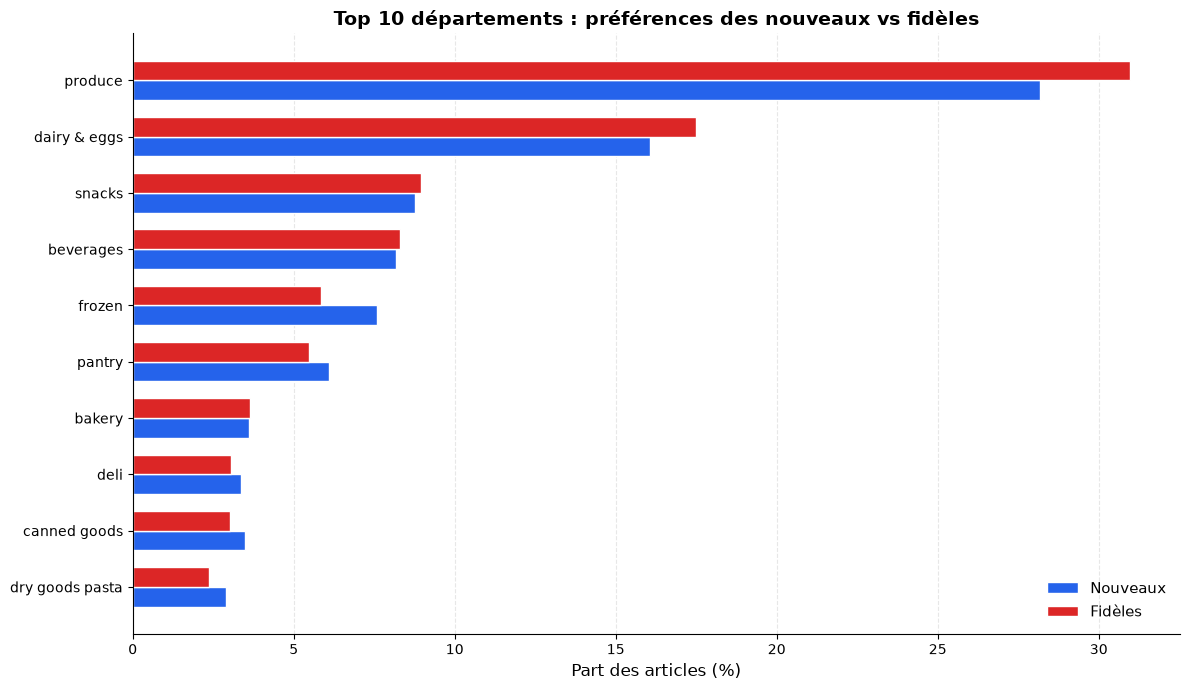

In [62]:
# Q10 Graphique 1 : Top 10 départements, comparaison Nouveaux vs Fidèles
fig, ax = plt.subplots(figsize=(12, 7))

# Sélectionner les top 10 départements par volume total
top_depts = dept_seg_pivot.sum(axis=1).nlargest(10).index.tolist()
data_for_chart = dept_seg_pct.loc[top_depts, ['Nouveaux', 'Fidèles', 'dept_name']].sort_values('Fidèles', ascending=True)

y_pos = np.arange(len(data_for_chart))
bar_height = 0.35

ax.barh(
    y_pos - bar_height / 2,
    data_for_chart['Nouveaux'],
    bar_height,
    label='Nouveaux',
    color=COLORS["segment_new"],
    edgecolor='white',
)
ax.barh(
    y_pos + bar_height / 2,
    data_for_chart['Fidèles'],
    bar_height,
    label='Fidèles',
    color=COLORS["segment_loyal"],
    edgecolor='white',
)

ax.set_yticks(y_pos)
ax.set_yticklabels(data_for_chart['dept_name'], fontsize=10)
ax.set_xlabel('Part des articles (%)', fontsize=12)
ax.set_title('Top 10 départements : préférences des nouveaux vs fidèles', fontsize=14, fontweight='bold')
ax.legend(frameon=False, fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()


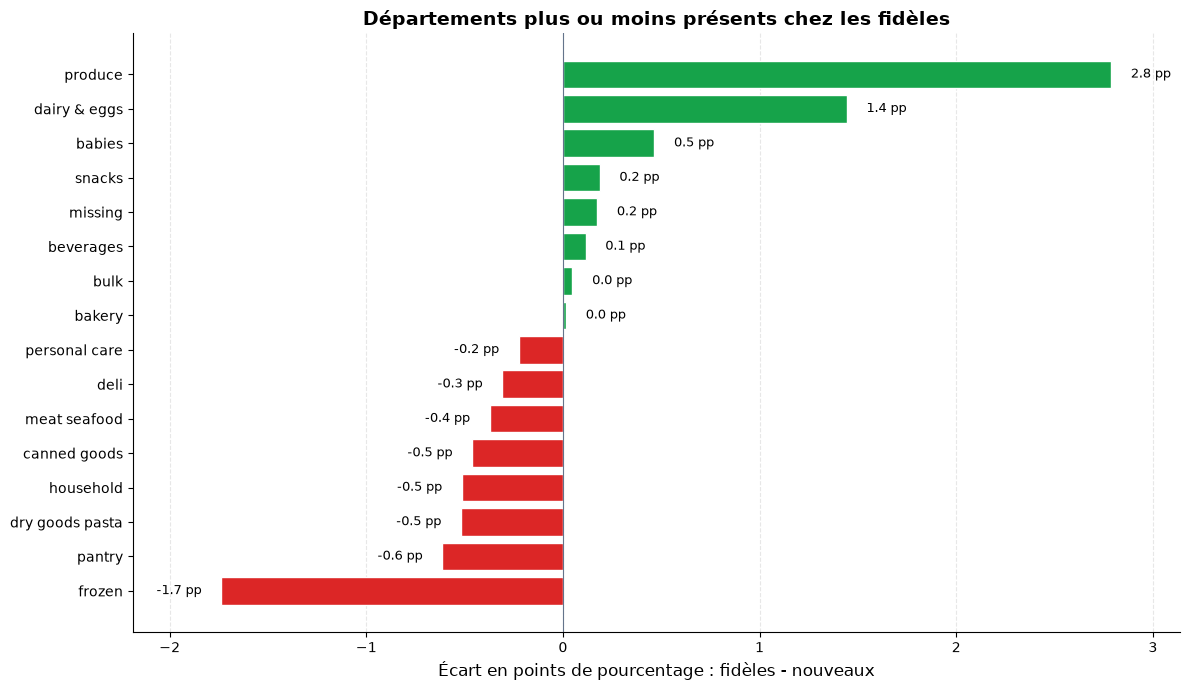

In [63]:
# Q10 Graphique 2 : Écarts entre fidèles et nouveaux (points de pourcentage)
fig, ax = plt.subplots(figsize=(12, 7))

# Trier par écart décroissant et prendre top 15 (positifs et négatifs)
ecarts_sorted = dept_seg_pct.sort_values('Ecart', ascending=True)
top_15_ecarts = pd.concat([ecarts_sorted.head(8), ecarts_sorted.tail(8)])

y_pos_ecart = np.arange(len(top_15_ecarts))
colors_ecart = [
    COLORS["negative"] if value < 0 else COLORS["positive"]
    for value in top_15_ecarts['Ecart']
]

bars = ax.barh(y_pos_ecart, top_15_ecarts['Ecart'], color=colors_ecart, edgecolor='white')

for bar, value in zip(bars, top_15_ecarts['Ecart']):
    ax.text(
        value + (0.1 if value > 0 else -0.1),
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f} pp',
        va='center',
        ha='left' if value > 0 else 'right',
        fontsize=9,
    )

x_min = top_15_ecarts['Ecart'].min()
x_max = top_15_ecarts['Ecart'].max()
ax.set_xlim(x_min - 0.45, x_max + 0.35)
ax.set_yticks(y_pos_ecart)
ax.set_yticklabels(top_15_ecarts['dept_name'], fontsize=10)
ax.set_xlabel('Écart en points de pourcentage : fidèles - nouveaux', fontsize=12)
ax.set_title('Départements plus ou moins présents chez les fidèles', fontsize=14, fontweight='bold')
ax.axvline(x=0, color=COLORS["neutral"], linestyle='-', linewidth=0.8)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()


## Observations

- Les fidèles achètent un peu plus de **fruits et légumes** (31 % contre 28 % pour les nouveaux) et de **produits laitiers et œufs** (17,5 % contre 16 %).
- Les surgelés prennent moins de place chez les fidèles (5,8 % contre 7,6 %). Les grandes catégories restent toutefois les mêmes.

## Recommandation

Sécuriser les rayons de produits frais et de base, qui prennent davantage d'importance chez les clients fidèles.

**Actions stratégiques**

- Garantir la disponibilité des fruits, légumes, produits laitiers et œufs.
- Proposer aux nouveaux des produits complémentaires issus de ces rayons.
- Utiliser des promotions ciblées pour relancer l'intérêt pour les catégories moins achetées, comme les surgelés.

---

### Q11. Quand commandent les fidèles, comparés aux nouveaux ?

**Question posée**

Les nouveaux clients et les fidèles commandent-ils aux mêmes moments ?

**Méthode**

- Nous comptons les commandes par jour et par heure pour chaque segment.
- Nous comparons les créneaux les plus fréquents des nouveaux et des fidèles.

**Visualisation** : les cartes de chaleur donnent une vue jour par jour ; les courbes facilitent la comparaison des heures.

In [64]:
# Q11 : Vérifications et calculs
print("="*60)
print("Q11 : Quand commandent les fidèles ?")
print("="*60)

# Vérifier les colonnes
required_cols_q11 = ['order_dow', 'order_hour_of_day', 'segment']
assert all(col in df_full_analysis.columns for col in required_cols_q11), "Colonnes manquantes"
print("✓ Colonnes vérifiées")

# Créer une table au niveau commande (pas article) pour éviter de compter la même commande N fois
df_orders_for_timing = df_full_analysis[['order_id', 'order_dow', 'order_hour_of_day', 'segment']].drop_duplicates(subset=['order_id'])

print(f"\n✓ {len(df_orders_for_timing)} commandes analysées")
print(f"✓ Distribution par segment :")
print(df_orders_for_timing['segment'].value_counts())

# Matrice jour × heure par segment
# Pour chaque segment, créer la distribution

# Nouveaux clients
nouveaux_data = df_orders_for_timing[df_orders_for_timing['segment'] == 'Nouveaux']
nouveaux_matrix = pd.crosstab(nouveaux_data['order_dow'], nouveaux_data['order_hour_of_day'], normalize='all') * 100

# Fidèles clients
fideles_data = df_orders_for_timing[df_orders_for_timing['segment'] == 'Fidèles']
fideles_matrix = pd.crosstab(fideles_data['order_dow'], fideles_data['order_hour_of_day'], normalize='all') * 100

print("\n✓ Matrices jour×heure construites (% du total par segment)")
print(f"Nouveaux : {nouveaux_matrix.sum().sum():.1f}% couvert")
print(f"Fidèles : {fideles_matrix.sum().sum():.1f}% couvert")

# Statistiques par jour
print("\n✓ Distribution par jour :")
day_nouveaux = df_orders_for_timing[df_orders_for_timing['segment'] == 'Nouveaux']['order_dow'].value_counts(normalize=True).sort_index() * 100
day_fideles = df_orders_for_timing[df_orders_for_timing['segment'] == 'Fidèles']['order_dow'].value_counts(normalize=True).sort_index() * 100
print("Nouveaux:", day_nouveaux.round(1).to_dict())
print("Fidèles :", day_fideles.round(1).to_dict())

# Statistiques par heure
print("\n✓ Distribution par heure :")
hour_nouveaux = df_orders_for_timing[df_orders_for_timing['segment'] == 'Nouveaux']['order_hour_of_day'].value_counts(normalize=True).sort_index() * 100
hour_fideles = df_orders_for_timing[df_orders_for_timing['segment'] == 'Fidèles']['order_hour_of_day'].value_counts(normalize=True).sort_index() * 100
print(f"Heure pic nouveaux : {hour_nouveaux.idxmax()}h ({hour_nouveaux.max():.1f}%)")
print(f"Heure pic fidèles : {hour_fideles.idxmax()}h ({hour_fideles.max():.1f}%)")


Q11 : Quand commandent les fidèles ?
✓ Colonnes vérifiées

✓ 3214874 commandes analysées
✓ Distribution par segment :
segment
Transitionnels    1520985
Nouveaux           963483
Fidèles            730406
Name: count, dtype: int64

✓ Matrices jour×heure construites (% du total par segment)
Nouveaux : 100.0% couvert
Fidèles : 100.0% couvert

✓ Distribution par jour :
Nouveaux: {0: 18.3, 1: 17.1, 2: 13.6, 3: 12.6, 4: 12.0, 5: 12.7, 6: 13.6}
Fidèles : {0: 15.3, 1: 17.6, 2: 14.1, 3: 13.6, 4: 13.4, 5: 14.1, 6: 12.0}

✓ Distribution par heure :
Heure pic nouveaux : 15h (8.4%)
Heure pic fidèles : 10h (9.0%)


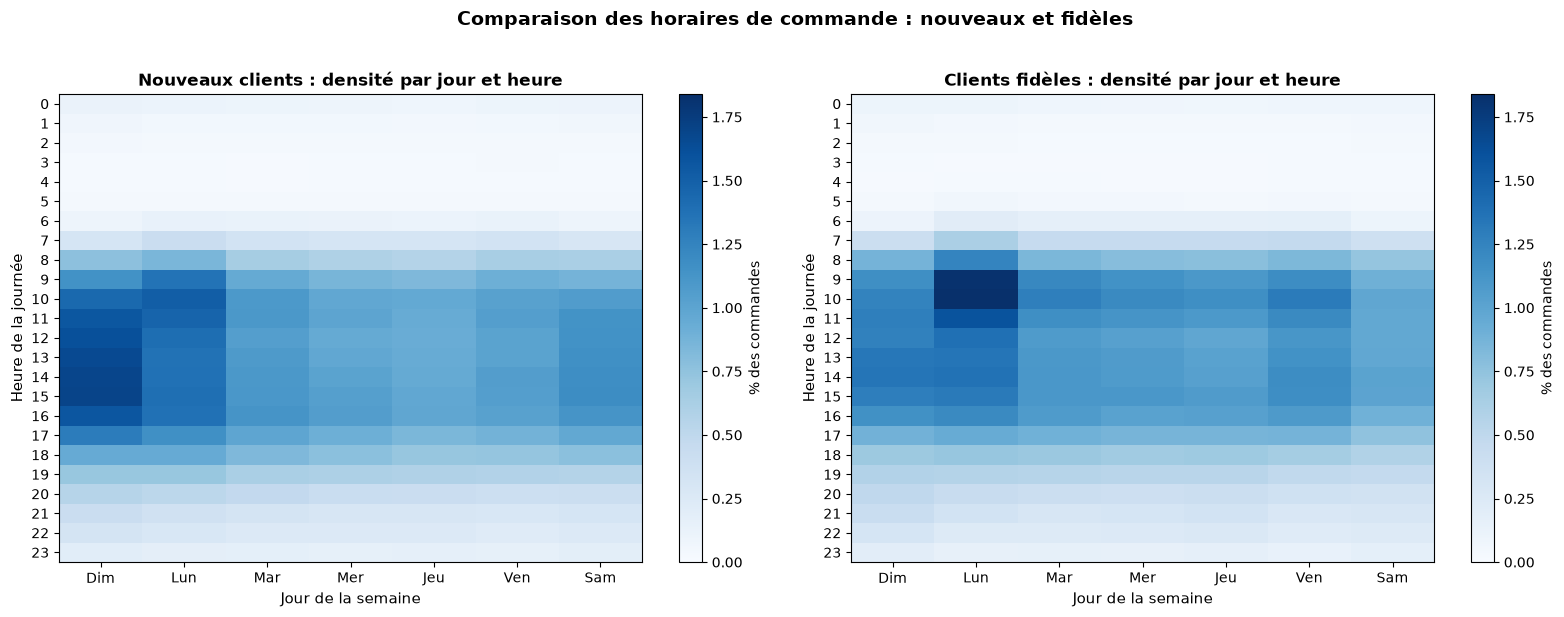

In [65]:
# Q11 Graphique 1 : Heatmap jour×heure pour Nouveaux vs Fidèles
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Normaliser les données pour heatmap lisible
nouveaux_heat = pd.crosstab(nouveaux_data['order_dow'], nouveaux_data['order_hour_of_day'], normalize='all') * 100
fideles_heat = pd.crosstab(fideles_data['order_dow'], fideles_data['order_hour_of_day'], normalize='all') * 100

# Aligner les colonnes et utiliser la même échelle de bleu pour comparer les segments
all_hours = sorted(set(nouveaux_heat.columns) | set(fideles_heat.columns))
nouveaux_heat = nouveaux_heat.reindex(columns=all_hours, fill_value=0)
fideles_heat = fideles_heat.reindex(columns=all_hours, fill_value=0)
heatmap_max = max(nouveaux_heat.to_numpy().max(), fideles_heat.to_numpy().max())

im1 = ax1.imshow(
    nouveaux_heat.T,
    aspect='auto',
    cmap='Blues',
    interpolation='nearest',
    vmin=0,
    vmax=heatmap_max,
)
ax1.set_xticks(range(7))
ax1.set_xticklabels(DOW_LABELS)
ax1.set_yticks(range(len(all_hours)))
ax1.set_yticklabels(all_hours)
ax1.set_title('Nouveaux clients : densité par jour et heure', fontsize=12, fontweight='bold')
ax1.set_xlabel('Jour de la semaine', fontsize=11)
ax1.set_ylabel('Heure de la journée', fontsize=11)
fig.colorbar(im1, ax=ax1, label='% des commandes')

im2 = ax2.imshow(
    fideles_heat.T,
    aspect='auto',
    cmap='Blues',
    interpolation='nearest',
    vmin=0,
    vmax=heatmap_max,
)
ax2.set_xticks(range(7))
ax2.set_xticklabels(DOW_LABELS)
ax2.set_yticks(range(len(all_hours)))
ax2.set_yticklabels(all_hours)
ax2.set_title('Clients fidèles : densité par jour et heure', fontsize=12, fontweight='bold')
ax2.set_xlabel('Jour de la semaine', fontsize=11)
ax2.set_ylabel('Heure de la journée', fontsize=11)
fig.colorbar(im2, ax=ax2, label='% des commandes')

fig.suptitle('Comparaison des horaires de commande : nouveaux et fidèles', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()


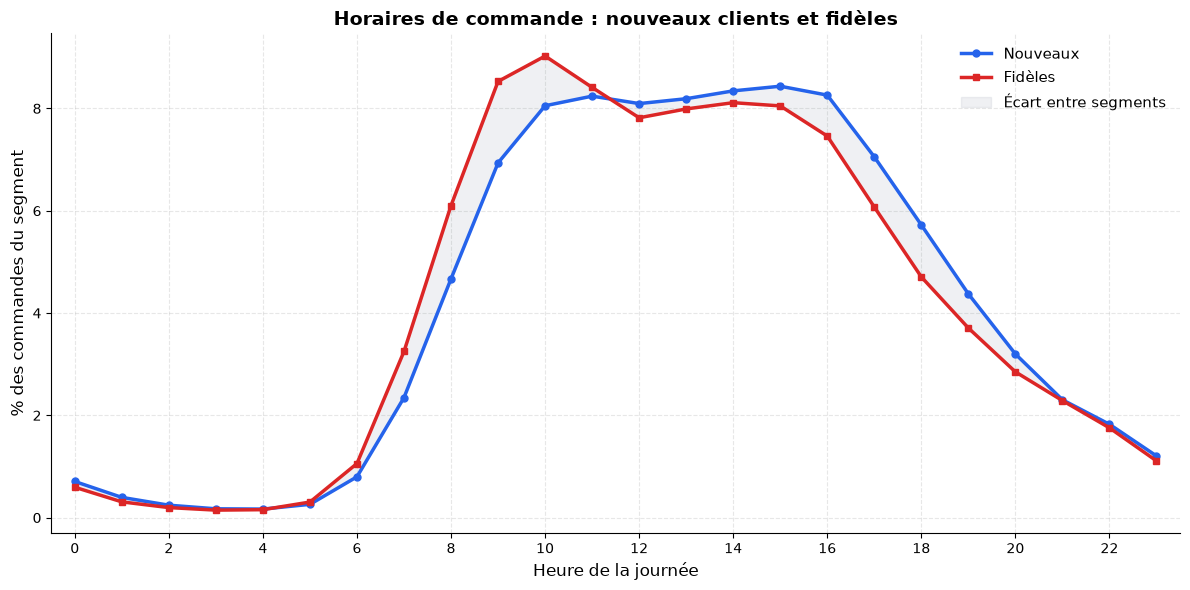

In [66]:
# Q11 Graphique 2 : Courbes de distribution par heure de la journée
fig, ax = plt.subplots(figsize=(12, 6))

# Compter par heure pour chaque segment
hour_dist_nouveaux = nouveaux_data['order_hour_of_day'].value_counts(normalize=True).sort_index() * 100
hour_dist_fideles = fideles_data['order_hour_of_day'].value_counts(normalize=True).sort_index() * 100

# Aligner les indices
all_hours_list = sorted(set(hour_dist_nouveaux.index) | set(hour_dist_fideles.index))
hour_dist_nouveaux = hour_dist_nouveaux.reindex(all_hours_list, fill_value=0)
hour_dist_fideles = hour_dist_fideles.reindex(all_hours_list, fill_value=0)

ax.plot(
    all_hours_list,
    hour_dist_nouveaux.values,
    marker='o',
    linewidth=2.5,
    label='Nouveaux',
    color=COLORS["segment_new"],
    markersize=5,
)
ax.plot(
    all_hours_list,
    hour_dist_fideles.values,
    marker='s',
    linewidth=2.5,
    label='Fidèles',
    color=COLORS["segment_loyal"],
    markersize=5,
)
ax.fill_between(
    all_hours_list,
    hour_dist_nouveaux.values,
    hour_dist_fideles.values,
    alpha=0.1,
    color=COLORS["neutral"],
    label='Écart entre segments',
)

ax.set_xlabel('Heure de la journée', fontsize=12)
ax.set_ylabel('% des commandes du segment', fontsize=12)
ax.set_title('Horaires de commande : nouveaux clients et fidèles', fontsize=14, fontweight='bold')
ax.legend(frameon=False, fontsize=11)
ax.grid(linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
ax.set_xticks(range(0, 24, 2))
ax.set_xlim(-0.5, 23.5)

fig.tight_layout()
plt.show()


## Observations

- Les deux segments commandent surtout pendant la journée, mais leur créneau le plus fréquent diffère.
- Le pic des nouveaux clients est le **dimanche à 15 h** ; celui des fidèles est le **lundi à 10 h**.

## Recommandation

Adapter l'organisation et les messages aux créneaux les plus actifs de chaque type de client.

**Actions stratégiques**

- Prévoir davantage de capacité de préparation et de livraison sur les créneaux de forte demande.
- Programmer les rappels à une heure proche des habitudes de commande du client.

---

### Q12. À quel moment un client risque-t-il d'abandonner ?

**Question posée**

Peut-on repérer un délai inhabituel avant qu'un client ne cesse de commander ?

**Méthode**

- Nous suivons la part de clients qui atteint chaque nouvelle commande et les délais entre deux commandes.
- Le troisième quartile des délais observés hors valeur censurée est utilisé comme seuil statistique de risque.
- Le dataset ne confirme pas un abandon réel et plafonne les délais à 30 jours ; on parle donc de risque, pas de certitude.

**Visualisation** : la courbe montre la baisse du nombre de clients au fil des commandes ; l'histogramme distingue les délais observés des délais plafonnés à 30 jours.

In [67]:
# Q12 : Vérifications et calculs
print("="*60)
print("Q12 : À quel moment un client risque-t-il d'abandonner ?")
print("="*60)

# Limites du dataset
print("\nLIMITES DU DATASET :")
print("  - Pas de date absolue de fin d'observation : inactivité ne signifie pas forcément abandon.")
print("  - Délai maximal observé : 30 jours. Les délais supérieurs sont censurés à cette valeur.")
print("  - Biais de survie : les clients avant leur deuxième commande sont moins observables.")
print("  - Interprétation : 'risque' désigne un signal de non-retour dans la fenêtre observée.")

# Analyse de rétention : à chaque commande N, quelle part de clients atteint N ?
retention = df_commandes.groupby('order_number').size().reset_index(name='count')
retention['retention_rate'] = retention['count'] / retention['count'].iloc[0] * 100
retention['churn_rate'] = 100 - retention['retention_rate']

print("\nRétention par rang de commande (% des clients ayant passé la commande 1) :")
print(retention[['order_number', 'count', 'retention_rate']].head(20))

# Les premières commandes n'ont pas de délai antérieur ; les NaN sont donc exclus.
delays = df_orders['days_since_prior_order'].dropna()
delays_observed = delays[delays < 30]
print("\nDélais entre commandes :")
print(f"  Moyenne totale : {delays.mean():.1f} jours")
print(f"  Médiane totale : {delays.median():.0f} jours")
print(f"  Q3 hors délais censurés : {delays_observed.quantile(0.75):.0f} jours")
print(f"  Valeurs à exactement 30 jours (censurées) : {(delays == 30).sum() / len(delays) * 100:.1f}%")

# Le seuil statistique est calculé hors plafond ; le seuil opérationnel reste fixé à 15 jours.
q3_delay = delays_observed.quantile(0.75)
print(f"\nSeuil statistique de risque : {q3_delay:.0f} jours (Q3 hors censure)")
print("Seuil opérationnel de relance : 15 jours")

# Recalcul local des segments pour garder cette cellule indépendante de Q9.
client_max_order_q12 = df_commandes.groupby('user_id')['order_number'].max()
client_segments_q12 = pd.cut(
    client_max_order_q12,
    bins=[0, 5, 25, float('inf')],
    labels=['Nouveaux', 'Transitionnels', 'Fidèles'],
    include_lowest=True,
)
print("\nDélais moyens par segment :")
for segment in ['Nouveaux', 'Fidèles']:
    segment_users = client_segments_q12[client_segments_q12 == segment].index
    seg_delays = df_commandes[
        df_commandes['user_id'].isin(segment_users)
    ]['days_since_prior_order'].dropna()
    print(f"  {segment}: moy={seg_delays.mean():.1f}j, médiane={seg_delays.median():.0f}j, Q3={seg_delays.quantile(0.75):.0f}j")

Q12 : À quel moment un client risque-t-il d'abandonner ?

LIMITES DU DATASET :
  - Pas de date absolue de fin d'observation : inactivité ne signifie pas forcément abandon.
  - Délai maximal observé : 30 jours. Les délais supérieurs sont censurés à cette valeur.
  - Biais de survie : les clients avant leur deuxième commande sont moins observables.
  - Interprétation : 'risque' désigne un signal de non-retour dans la fenêtre observée.

Rétention par rang de commande (% des clients ayant passé la commande 1) :
    order_number   count  retention_rate
0              1  206209      100.000000
1              2  206209      100.000000
2              3  206209      100.000000
3              4  182223       88.368112
4              5  162633       78.868042
5              6  146468       71.028908
6              7  132618       64.312421
7              8  120918       58.638566
8              9  110728       53.696977
9             10  101696       49.316955
10            11   93881       45.52

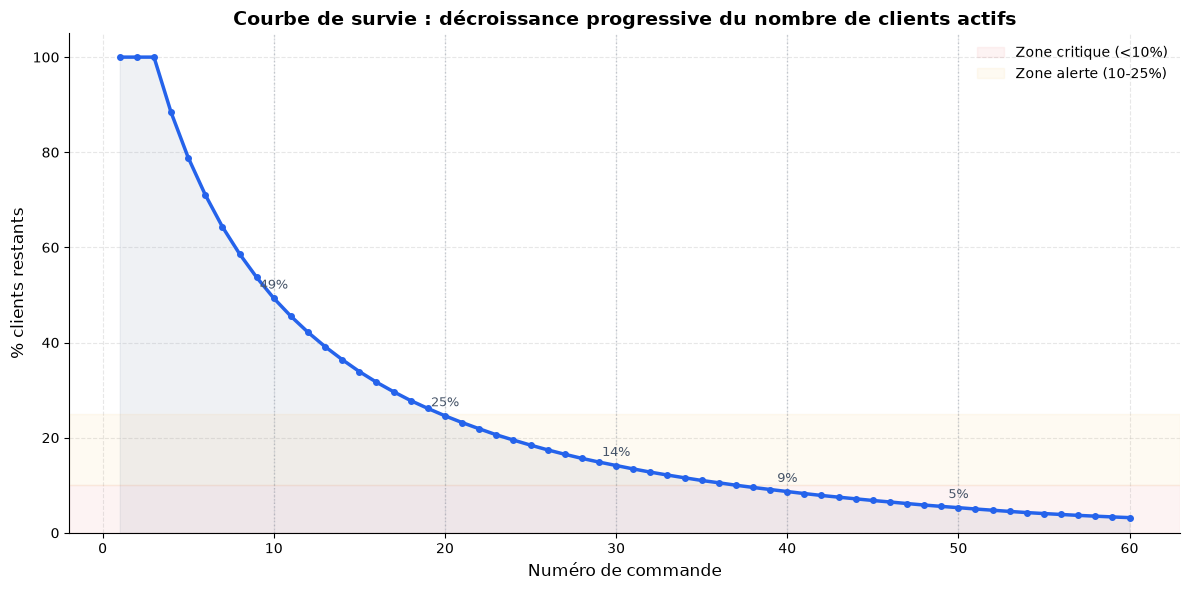


✓ Points clés de rétention :
  Commande # 5 :  78.9% des clients passent à cette étape
  Commande #10 :  49.3% des clients passent à cette étape
  Commande #15 :  33.9% des clients passent à cette étape
  Commande #20 :  24.6% des clients passent à cette étape
  Commande #25 :  18.4% des clients passent à cette étape


In [68]:
# Q12 Graphique 1 : Courbe de survie / rétention par numéro de commande
fig, ax = plt.subplots(figsize=(12, 6))

# Limiter à un nombre de commandes affichable
max_order_to_plot = 60
retention_plot = retention[retention['order_number'] <= max_order_to_plot].copy()

ax.plot(
    retention_plot['order_number'],
    retention_plot['retention_rate'],
    linewidth=2.5,
    marker='o',
    markersize=4,
    color=COLORS['line'],
)
ax.fill_between(
    retention_plot['order_number'],
    retention_plot['retention_rate'],
    alpha=0.15,
    color=COLORS['fill'],
)

# Ajouter des repères de perte progressive
milestones = [10, 20, 30, 40, 50]
for order in milestones:
    if order <= max_order_to_plot:
        ret_val = retention[retention['order_number'] == order]['retention_rate'].values
        if len(ret_val) > 0:
            ax.axvline(x=order, color=COLORS["neutral"], linestyle=':', alpha=0.3, linewidth=1)
            ax.text(order, ret_val[0] + 2, f'{ret_val[0]:.0f}%', ha='center', fontsize=9, color=COLORS["annotation"])

ax.axhspan(0, 10, alpha=0.05, color=COLORS["negative"], label='Zone critique (<10%)')
ax.axhspan(10, 25, alpha=0.05, color=COLORS["warning"], label='Zone alerte (10-25%)')

ax.set_xlabel('Numéro de commande', fontsize=12)
ax.set_ylabel('% clients restants', fontsize=12)
ax.set_title('Courbe de survie : décroissance progressive du nombre de clients actifs', fontsize=14, fontweight='bold')
ax.legend(frameon=False, fontsize=10, loc='upper right')
ax.grid(linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
ax.set_ylim(0, 105)

fig.tight_layout()
plt.show()

print('\n✓ Points clés de rétention :')
for order in [5, 10, 15, 20, 25]:
    ret = retention[retention['order_number'] == order]['retention_rate'].values
    if len(ret) > 0:
        print(f'  Commande #{order:2d} : {ret[0]:5.1f}% des clients passent à cette étape')


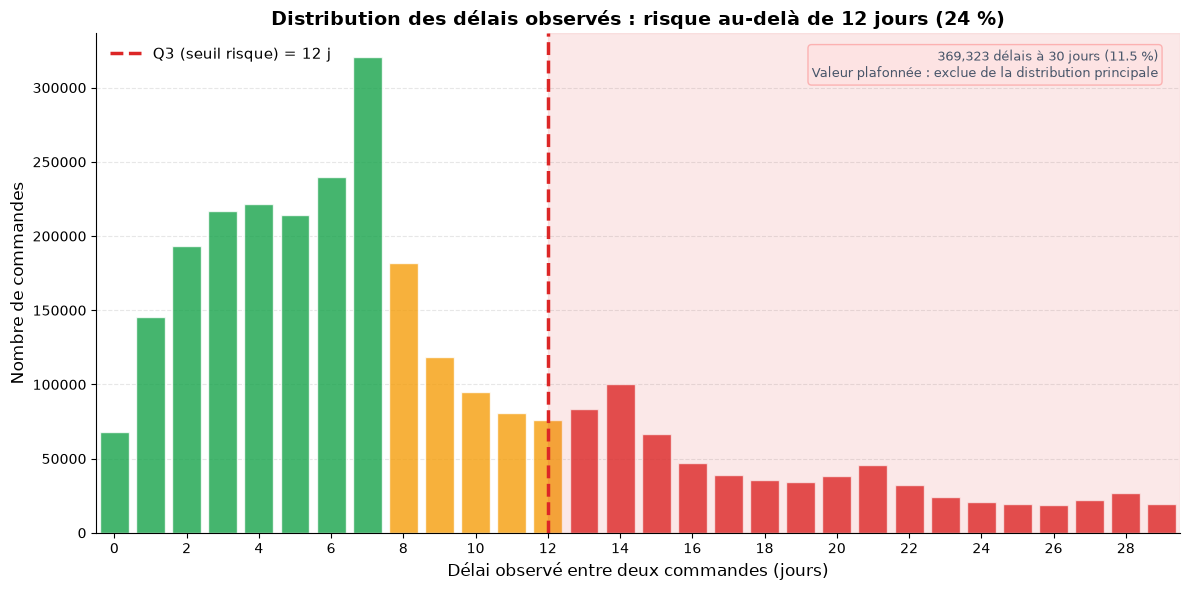


✓ Seuil de risque appliqué : 12 jours
  -> 23.7% des délais observés dépassent ce seuil
  -> 369,323 délais (11.5%) sont censurés à 30 jours


In [69]:
# Q12 Graphique 2 : Distribution des délais observés hors valeur censurée à 30 jours
fig, ax = plt.subplots(figsize=(12, 6))

# Le dataset plafonne les délais à 30 jours : cette valeur ne signifie pas
# nécessairement un retour exactement à J+30. Elle est exclue du graphique
# principal et présentée séparément comme valeur censurée.
delays_all = df_orders['days_since_prior_order'].dropna()
delays_observed = delays_all[delays_all < 30]
delays_censored = delays_all[delays_all == 30]
bins_delays = np.arange(-0.5, 30.5, 1)
counts, edges = np.histogram(delays_observed, bins=bins_delays)
centers = np.arange(0, 30)

colors_bars = []
q3_val = delays_observed.quantile(0.75)
for center in centers:
    if center <= 7:
        colors_bars.append(COLORS["positive"])
    elif center <= q3_val:
        colors_bars.append(COLORS["warning"])
    else:
        colors_bars.append(COLORS["negative"])

ax.bar(centers, counts, width=0.8, color=colors_bars, edgecolor='white', alpha=0.8)

ax.axvline(
    x=q3_val,
    color=COLORS["negative"],
    linestyle='--',
    linewidth=2.5,
    label=f'Q3 (seuil risque) = {q3_val:.0f} j',
)
ax.axvspan(q3_val, 29.5, alpha=0.1, color=COLORS["negative"])
ax.text(
    0.98,
    0.97,
    f"{len(delays_censored):,} délais à 30 jours ({len(delays_censored) / len(delays_all) * 100:.1f} %)\n"
    "Valeur plafonnée : exclue de la distribution principale",
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=9,
    color=COLORS["annotation"],
    bbox=dict(boxstyle='round', facecolor=COLORS["light_negative"], edgecolor=COLORS["border_negative"], alpha=0.8),
)

pct_beyond_q3 = (delays_observed > q3_val).sum() / len(delays_observed) * 100

ax.set_xlabel('Délai observé entre deux commandes (jours)', fontsize=12)
ax.set_ylabel('Nombre de commandes', fontsize=12)
ax.set_title(
    f"Distribution des délais observés : risque au-delà de {q3_val:.0f} jours ({pct_beyond_q3:.0f} %)",
    fontsize=14,
    fontweight='bold',
)
ax.set_xlim(-0.5, 29.5)
ax.set_xticks(range(0, 30, 2))
ax.legend(frameon=False, fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

print(f'\n✓ Seuil de risque appliqué : {q3_val:.0f} jours')
print(f'  -> {pct_beyond_q3:.1f}% des délais observés dépassent ce seuil')
print(f'  -> {len(delays_censored):,} délais ({len(delays_censored) / len(delays_all) * 100:.1f}%) sont censurés à 30 jours')

## Observations

- La part de clients qui poursuit son parcours baisse régulièrement : 79 % atteignent la 5e commande, 49 % la 10e et 18 % la 25e.
- Le troisième quartile des délais non censurés est de **12 jours** : au-delà, le délai devient statistiquement moins fréquent.
- Les délais à **30 jours** représentent 11,5 % des mesures, mais cette valeur est plafonnée par le dataset et peut regrouper des délais plus longs.

## Recommandation

Mettre en place une rétention progressive, en intervenant plus tôt pour les clients dont le rythme ralentit.

**Actions stratégiques**

- Accompagner les 5 premières commandes pour favoriser le retour.
- Utiliser 12 jours comme seuil statistique de surveillance et 15 jours comme seuil opérationnel de relance.
- Proposer une offre de réactivation après 21 jours, tout en gardant en tête la censure des délais à 30 jours.

---

## Synthèse du Bloc C

- Les clients fidèles sont moins nombreux, mais pèsent davantage dans le volume d'articles.
- Leurs achats se concentrent un peu plus sur les produits frais et les produits laitiers et œufs.
- Un délai de plus de 15 jours est un signal utile pour relancer un client, sans prouver un abandon.

## Recommandations

- Donner des avantages ciblés aux clients fidèles et actifs.
- Aider les clients transitionnels à commander plus régulièrement.
- Déclencher une relance personnalisée quand le rythme habituel d'un client ralentit.

---

---

## Bloc D : Modélisation (prédire le retour rapide d'un client)

Nous posons au modèle une question simple et directement actionnable :

**« Ce client va-t-il repasser commande dans les 15 jours ? »**

- **1 (retour rapide)** : la commande suivante arrive en 15 jours ou moins (client actif).
- **0 (retour lent)** : le délai dépasse 15 jours (client à risque de décrochage, à relancer).

*Pourquoi 15 jours ?* C'est le seuil de rupture identifié dans le Bloc C, et il évite le piège des délais plafonnés à 30 jours du dataset.

### Construction du jeu de données

Chaque client est représenté par **une seule ligne** : sa dernière commande sert de cible, et ses commandes précédentes servent à calculer ses habitudes.

| Variable | Signification métier |
|---|---|
| `nb_commandes` | Ancienneté du client |
| `delai_moyen`, `delai_median`, `delai_std` | Rythme d'achat habituel et sa régularité |
| `delai_dernier` | Dernier délai observé (signal de ralentissement) |
| `part_delais_longs` | Fréquence des pauses de plus de 15 jours |
| `panier_moyen`, `panier_dernier` | Volume habituel et récent |
| `part_reachat` | Part de produits déjà connus |
| `heure_moyenne` | Créneau horaire habituel |

Traitement automatisé dans [src/ml_features.py](src/ml_features.py) (`build_ml_dataset`).

In [70]:
from src.ml_features import SEUIL_RETOUR_RAPIDE, build_ml_dataset

df_ml = build_ml_dataset(df_commandes)
FEATURES = [col for col in df_ml.columns if col not in ("user_id", "retour_rapide")]

nb_clients_total = df_commandes["user_id"].nunique()
print(f"Clients retenus : {len(df_ml):,} sur {nb_clients_total:,}")
print(f"Variables explicatives : {len(FEATURES)}")
print(f"Part de retours rapides (≤ {SEUIL_RETOUR_RAPIDE} jours) : {df_ml['retour_rapide'].mean():.1%}")
df_ml.head()

Clients retenus : 182,223 sur 206,209
Variables explicatives : 10
Part de retours rapides (≤ 15 jours) : 57.1%


,user_id,nb_commandes,panier_moyen,panier_dernier,part_reachat,delai_moyen,delai_median,delai_std,delai_dernier,part_delais_longs,heure_moyenne,retour_rapide
0,1,9,5.555556,6,0.710185,18.250000,19.5,9.130013,0.0,0.750000,10.555556,0
1,2,13,13.769231,9,0.434343,15.416667,11.5,10.282008,30.0,0.333333,10.615385,1
2,3,11,7.454545,5,0.627801,11.800000,10.0,5.573748,11.0,0.300000,16.545455,1
3,4,4,3.750000,2,0.035714,18.333333,19.0,3.055050,15.0,1.000000,12.500000,1
4,5,3,8.333333,5,0.281481,10.500000,10.5,0.707107,10.0,0.000000,15.333333,0


**Équilibre des classes** : **57 % de retours rapides** contre **43 % de retours lents**.

Le jeu de données est équilibré. Une prédiction naïve (répondre toujours « retour rapide ») donnerait 57 % d'exactitude : c'est notre **baseline** à battre.

### Séparation entraînement / test

Nous isolons **20 % des clients pour le test final**. Ces clients ne sont jamais vus pendant l'entraînement afin de mesurer la performance en conditions réelles.

In [71]:
from sklearn.model_selection import train_test_split

X = df_ml[FEATURES]
y = df_ml["retour_rapide"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Entraînement : {len(X_train):,} clients ({y_train.mean():.1%} de retours rapides)")
print(f"Test         : {len(X_test):,} clients ({y_test.mean():.1%} de retours rapides)")

Entraînement : 145,778 clients (57.1% de retours rapides)
Test         : 36,445 clients (57.1% de retours rapides)


### Modèles comparés

Nous comparons 4 modèles de complexité croissante :

1. **Baseline** : prédit toujours la classe majoritaire (plancher minimal à 57 %).
2. **Régression logistique** : modèle linéaire simple et très rapide.
3. **Forêt aléatoire** : combinaison d'arbres de décision.
4. **Gradient boosting** (`HistGradientBoostingClassifier`) : modèle performant sur données tabulaires.

Une **validation croisée (3 plis)** sur l'entraînement vérifie la stabilité des modèles avant le test final.

In [72]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

modeles = {
    "Baseline (classe majoritaire)": DummyClassifier(strategy="most_frequent"),
    "Régression logistique": Pipeline([
        ("standardisation", StandardScaler()),
        ("modele", LogisticRegression(max_iter=1000)),
    ]),
    "Forêt aléatoire": RandomForestClassifier(
        n_estimators=100, min_samples_leaf=20, n_jobs=-1, random_state=42
    ),
    "Gradient boosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=31,
        l2_regularization=0.05,
        random_state=42,
    ),
}

print("Validation croisée (3 plis, ROC-AUC) sur le jeu d'entraînement :")
for nom, modele in modeles.items():
    scores_cv = cross_val_score(modele, X_train, y_train, cv=3, scoring="roc_auc", n_jobs=-1)
    print(f"  {nom:<32} {scores_cv.mean():.3f} (± {scores_cv.std():.3f})")

Validation croisée (3 plis, ROC-AUC) sur le jeu d'entraînement :
  Baseline (classe majoritaire)    0.500 (± 0.000)
  Régression logistique            0.758 (± 0.002)
  Forêt aléatoire                  0.763 (± 0.002)
  Gradient boosting                0.765 (± 0.002)


Les écarts-types sont très faibles : les performances ne dépendent pas de l'échantillon tiré. On peut passer à l'évaluation finale sur le jeu de test.

### Évaluation sur le jeu de test

Nous évaluons les modèles sur plusieurs métriques :

- **Accuracy** : part globale de bonnes réponses.
- **Précision & Rappel** : équilibre entre détection des retours et fausses alertes.
- **ROC-AUC** : capacité à bien classer les clients du plus au moins à risque (de 0,5 à 1,0).

In [73]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

resultats = []
predictions = {}
for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    y_proba = modele.predict_proba(X_test)[:, 1]
    predictions[nom] = y_proba
    resultats.append({
        "Modèle": nom,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Précision": precision_score(y_test, y_pred, zero_division=0),
        "Rappel": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

df_resultats = pd.DataFrame(resultats).set_index("Modèle")
print(df_resultats.round(3).to_string())

meilleur_nom = df_resultats["ROC-AUC"].idxmax()
meilleur_modele = modeles[meilleur_nom]
print(f"\nModèle retenu : {meilleur_nom}")

                               Accuracy  Précision  Rappel     F1  ROC-AUC
Modèle                                                                    
Baseline (classe majoritaire)     0.571      0.571   1.000  0.727    0.500
Régression logistique             0.692      0.721   0.750  0.735    0.757
Forêt aléatoire                   0.695      0.733   0.732  0.733    0.763
Gradient boosting                 0.696      0.734   0.735  0.734    0.764

Modèle retenu : Gradient boosting


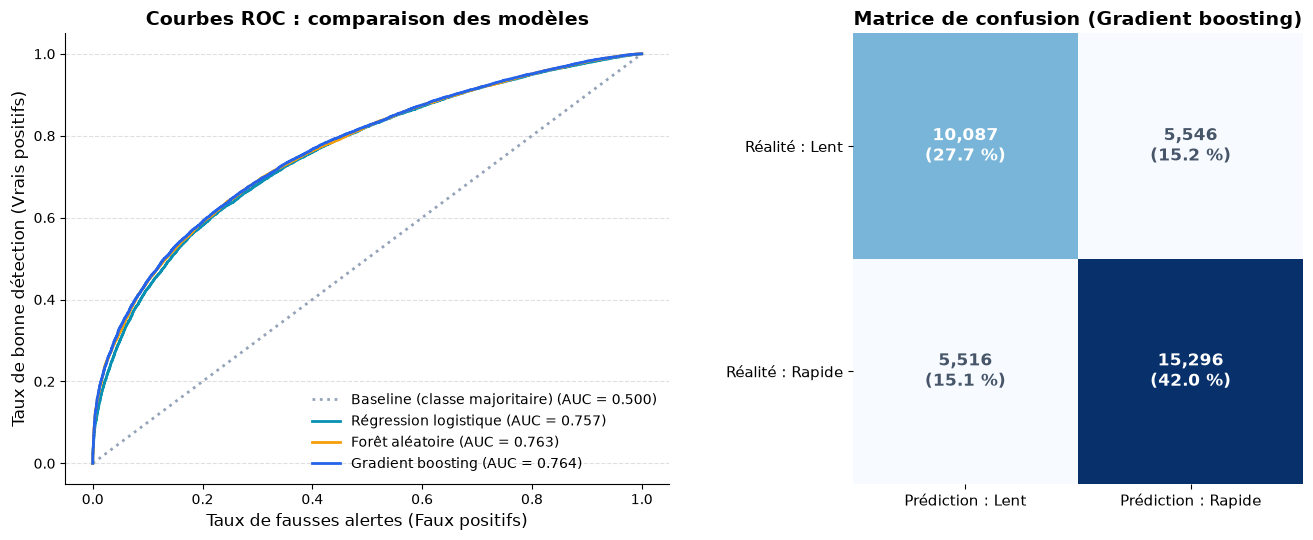

In [74]:
from sklearn.metrics import confusion_matrix, roc_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# 1. Courbes ROC
couleurs_modeles = {
    "Baseline (classe majoritaire)": COLORS["muted"],
    "Régression logistique": COLORS["secondary"],
    "Forêt aléatoire": COLORS["warning"],
    "Gradient boosting": COLORS["primary"],
}
for nom, y_proba in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = df_resultats.loc[nom, "ROC-AUC"]
    trait = ":" if nom.startswith("Baseline") else "-"
    ax1.plot(fpr, tpr, trait, color=couleurs_modeles[nom], linewidth=2, label=f"{nom} (AUC = {auc:.3f})")

style_chart(
    ax1,
    title="Courbes ROC : comparaison des modèles",
    xlabel="Taux de fausses alertes (Faux positifs)",
    ylabel="Taux de bonne détection (Vrais positifs)",
)

# 2. Matrice de confusion
cm = confusion_matrix(y_test, meilleur_modele.predict(X_test))
total = cm.sum()
ax2.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        val = cm[i, j]
        pct = val / total * 100
        couleur_texte = "white" if val > cm.max() / 2 else COLORS["annotation"]
        ax2.text(
            j, i,
            f"{val:,}\n({pct:.1f} %)",
            ha="center", va="center",
            fontsize=12, fontweight="bold", color=couleur_texte
        )
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["Prédiction : Lent", "Prédiction : Rapide"], fontsize=11)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["Réalité : Lent", "Réalité : Rapide"], fontsize=11)
ax2.set_title(f"Matrice de confusion ({meilleur_nom})", fontsize=14, fontweight="bold")
for spine in ax2.spines.values():
    spine.set_visible(False)

fig.tight_layout()
plt.show()

**Résultats sur le jeu de test** :

- Les modèles obtiennent environ 70 % de bonnes réponses, contre 57,1 % pour la baseline.
- Le Gradient Boosting obtient le meilleur ROC-AUC avec **0.764**, devant la forêt aléatoire (**0.763**) et la régression logistique (**0.757**).
- L'écart reste modéré, mais le Gradient Boosting est également en tête lors de la validation croisée, avec un ROC-AUC de **0.765**.
- La matrice de confusion montre des résultats relativement équilibrés entre les deux classes.

### Quelles variables influencent la prédiction ?

Pour le vérifier, nous mélangeons les valeurs d'une variable à la fois, puis nous regardons si le modèle devient moins performant.

- Si le score baisse beaucoup, la variable est utile pour la prédiction.
- Si le score change peu, la variable apporte peu d'information au modèle.

Le graphique présente donc les variables qui contribuent le plus à la prédiction du retour client.

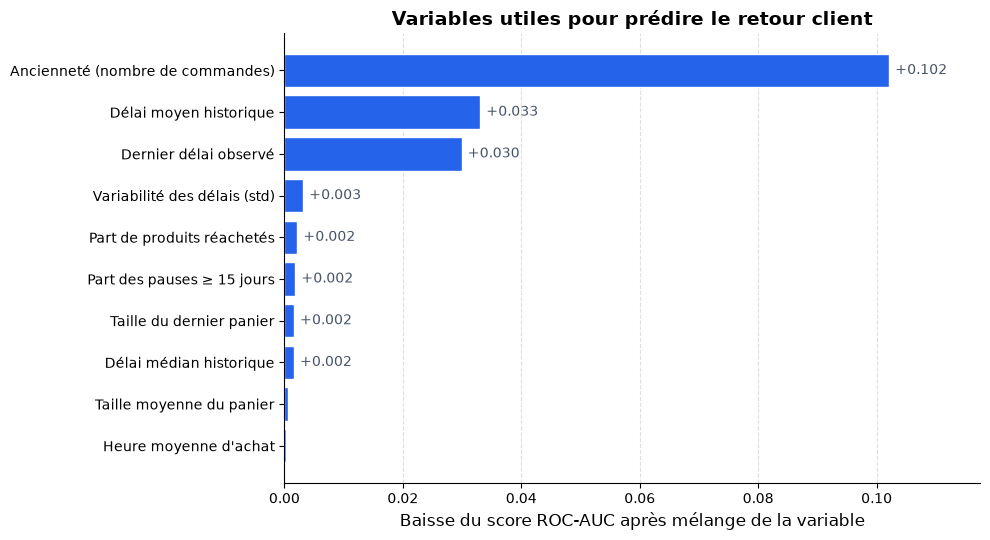

In [75]:
from sklearn.inspection import permutation_importance

importance = permutation_importance(
    meilleur_modele, X_test, y_test,
    n_repeats=5, scoring="roc_auc", random_state=42, n_jobs=-1,
)
imp = pd.Series(importance.importances_mean, index=FEATURES).sort_values()

FEATURE_LABELS = {
    "nb_commandes": "Ancienneté (nombre de commandes)",
    "delai_moyen": "Délai moyen historique",
    "delai_dernier": "Dernier délai observé",
    "delai_std": "Variabilité des délais (std)",
    "delai_median": "Délai médian historique",
    "part_delais_longs": "Part des pauses ≥ 15 jours",
    "part_reachat": "Part de produits réachetés",
    "panier_dernier": "Taille du dernier panier",
    "panier_moyen": "Taille moyenne du panier",
    "heure_moyenne": "Heure moyenne d'achat",
}
imp_renamed = imp.rename(index=FEATURE_LABELS)

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(imp_renamed.index, imp_renamed.values, color=COLORS["primary"], edgecolor="white")

for bar in bars:
    val = bar.get_width()
    if val > 0.001:
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f"+{val:.3f}", ha="left", va="center", fontsize=10, color=COLORS["annotation"])

style_chart(
    ax,
    title="Variables utiles pour prédire le retour client",
    xlabel="Baisse du score ROC-AUC après mélange de la variable",
    ylabel="",
    legend=False,
)
ax.set_xlim(0, max(imp_renamed.values) * 1.15)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()


## Interprétation

1. Le rythme d'achat est la principale source d'information pour prédire le retour : l'ancienneté (`nb_commandes`), le délai moyen et le dernier délai observé sont les variables les plus influentes.
2. La taille et le contenu du panier apportent peu d'information supplémentaire pour cette prédiction.

Le modèle confirme donc le résultat du Bloc B : la fidélité se traduit surtout par une fréquence de commande plus élevée.

### Du score à l'action : transformer le modèle en outil de ciblage

Le modèle attribue à chaque client un **score de risque de décrochage** (de 0 % à 100 %). Plus le score est élevé, plus le risque que le client dépasse 15 jours sans commander est fort.

Nous testons plusieurs seuils de déclenchement pour optimiser les relances commerciales :

In [76]:
proba_retour = meilleur_modele.predict_proba(X_test)[:, 1]
scores = pd.DataFrame({
    "user_id": df_ml.loc[X_test.index, "user_id"].values,
    "score_risque": 1 - proba_retour,
    "retour_lent_reel": 1 - y_test.values,
})

taux_base = scores["retour_lent_reel"].mean()
print(f"Sans modèle, relancer au hasard toucherait {taux_base:.0%} de vrais retours lents.\n")

print("Ciblage selon le seuil de score choisi :")
for seuil in (0.5, 0.6, 0.7, 0.8):
    cibles = scores[scores["score_risque"] >= seuil]
    print(
        f"  score >= {seuil:.1f} : {len(cibles):>6,} clients ({len(cibles) / len(scores):>4.0%} du test), "
        f"dont {cibles['retour_lent_reel'].mean():.0%} de vrais retours lents"
    )

print("\nLes 10 clients les plus à risque :")
print(scores.nlargest(10, "score_risque").round(3).to_string(index=False))

Sans modèle, relancer au hasard toucherait 43% de vrais retours lents.

Ciblage selon le seuil de score choisi :
  score >= 0.5 : 15,603 clients ( 43% du test), dont 65% de vrais retours lents
  score >= 0.6 : 10,185 clients ( 28% du test), dont 69% de vrais retours lents
  score >= 0.7 :  4,513 clients ( 12% du test), dont 75% de vrais retours lents
  score >= 0.8 :    618 clients (  2% du test), dont 85% de vrais retours lents

Les 10 clients les plus à risque :
 user_id  score_risque  retour_lent_reel
   57738         0.901                 1
  124743         0.899                 1
  109672         0.898                 1
  176423         0.894                 1
  106630         0.893                 1
   67804         0.891                 1
  137782         0.890                 1
  202570         0.890                 1
  199106         0.889                 1
  121725         0.889                 1


## Synthèse du Bloc D

- Avec un seuil de risque de 0,7, le modèle cible 13 % des clients et identifie 75 % des retours lents observés, contre 43 % avec une sélection aléatoire.
- Le ciblage permet de concentrer les relances sur les clients qui présentent le plus de risques de ralentissement.

### Recommandations

- Utiliser une relance plus incitative pour les scores de risque élevés et une notification simple pour les scores intermédiaires.
- Recalculer régulièrement les scores à partir de l'historique mis à jour.
- Tester l'efficacité réelle des relances avec un groupe témoin avant un déploiement général.

### Limites du modèle

- **Clients récents non couverts** : le jeu de données ne contient que des clients ayant au moins 4 commandes (biais de sélection de la source).
- **Délai plafonné dans l'historique** : les délais historiques restent plafonnés à 30 jours, ce qui sous-estime légèrement les très longues pauses passées.
- **Validation A/B conseillée** : valider l'impact réel des relances par un test A/B avant déploiement à 100 %.

---

## Synthèse globale

### Bloc A : Le client type

- Un client passe environ **10 commandes**, avec un panier médian de **8 articles**.
- Son rythme de retour habituel est de **7 jours**.

### Bloc B : L'habitude se construit

- La taille et la composition du panier changent peu.
- La fréquence de commande et le réachat des mêmes produits augmentent surtout pendant les **5 à 15 premières commandes**.

### Bloc C : Fidéliser au bon moment

- Les fidèles représentent 17 % des clients, mais 23 % du volume d'articles.
- Les 20 % de clients les plus actifs réalisent 60 % du volume.
- Les produits frais prennent davantage de place chez les fidèles, et un délai de plus de 15 jours est un signal d'alerte.

### Bloc D : Prédire pour agir

- Un modèle de gradient boosting prédit le retour d'un client sous 15 jours avec un **ROC-AUC de 0,76**.
- Le rythme d'achat passé (ancienneté et délais) porte l'essentiel de la prédiction.
- Cibler les scores de risque élevés rend la relance presque deux fois plus efficace qu'une relance au hasard.

## Actions prioritaires

- Personnaliser les suggestions dès la première commande.
- Envoyer un rappel autour de J+7 et une relance après 15 jours sans commande.
- Prioriser les relances avec le score de risque du modèle, en commençant par les scores les plus élevés.
- Réserver des avantages ciblés aux clients les plus actifs et sécuriser les produits de base.